<a href="https://colab.research.google.com/github/Maverick-Ansh/self-play-pretraining-zero-data/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-Play Pretraining with Zero Data, rebuilt from scratch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maverick-Ansh/self-play-pretraining-zero-data/blob/main/self_play_pretraining.ipynb)

**Paper:** Cowsik, Dolev, Li, De Luca, Cohen, Goodman, Levine. *Self-Play Pretraining with Zero Data.* arXiv:2609.30063 (Sep 2026).
**Hardware:** 2 × Tesla T4 (Kaggle backend, driven from Colab).  **Repo:** [Maverick-Ansh/self-play-pretraining-zero-data](https://github.com/Maverick-Ansh/self-play-pretraining-zero-data)

Two transformers start from random weights. Neither ever sees a single byte of natural data.

* The **generator** $g_\phi$ writes short programs for a tiny universal computer (Brainf\*ck plus ten macros).
* The machine runs each program and prints bytes.
* The **learner** $\pi_\theta$ learns to predict those bytes, one at a time.
* The generator is paid for programs whose outputs push the learner *further along the direction it is already learning*.

The paper's question: after this closed loop, can the learner predict **real** text, images, speech, music and DNA, and does that improve predictably with compute?

```
         +------------------ RL reward  r_i = |< grad L(y_i), P * (theta_past - theta_now) >| -----------------+
         |                                                                                                       |
 generator g_phi --- programs x_i --->  universal machine U --- bytes y_i = U(x_i, w_i) --->  learner pi_theta ---+
 (GRPO + KL to g0 + expert iteration)    (BF + 10 macros)                                     (next-byte CE)
```

## How this notebook is built

Bottom up. Each part writes one module of the `spp/` package with `%%writefile`, then tests it against a rule from the paper before anything is stacked on top of it.

| Part | Builds | Checked against |
|---|---|---|
| 1 | the universal machine $U$ | App. E example · Table 1 outputs · **6,143 programs the authors' generator discovered** |
| 2 | the byte transformer (learner and generator share it) | parameter counts of all 6 released models |
| 3 | the generator and the prior $g_0$ | at initialisation $g_\phi = g_0$ exactly |
| 4 | the reward (Eq. 2) by forward-mode autodiff | per-example autograd |
| 5 | the program pool (MAP-Elites mutation + replay) | App. G |
| 6 | the structure detector (Table 1) | the authors' detector, verbatim |
| 7 | evaluation: zero-shot bits/byte, a zero-training floor, ICL tasks | **the authors' released weights reproduce their published bits/byte to 3 decimals** |
| 8 | one round of self-play, then the loop | a live mini-run |
| 9 | the experiments on 2 GPUs | |
| 10 | results and verdicts | |

## What the paper claims, stated so it can fail

| # | Claim | Where | Confirmed here if |
|---|---|---|---|
| **C1** | Zero-shot bits/byte on held-out natural data falls as a power law in self-play compute, across modalities | Fig. 1, Fig. 2, Table 2 | the compute-optimal frontier over sizes × checkpoints falls on every modality and $L(C)=E+AC^{-\alpha}$ fits with $\alpha>0$ |
| **C2** | Self-play beats the *non-adaptive* universal prior over the **same** program space | Fig. 2, §3.1 | at equal size and tokens, self-play < uniform-prior bits/byte beyond seed spread |
| **C3** | What the reward says about each program matters, not just its distribution | Table 5 (`shuffle`) | permuting rewards across the pool loses to the canonical reward beyond seed spread |
| **C4** | The learner learns in context on tasks it never saw; the uniform-prior learner does not | Fig. 1, Fig. 4 | exact-match accuracy rises with the number of demonstrations $m$ for self-play, not for uniform |
| **C5** | The generator finds Fibonacci / geometric / quadratic / cubic sequences far sooner than uniform sampling | Table 1 | self-play pools contain these families at a rate well above the rate $g_0$ produces them by chance at the same tape length (measured on 10M programs) |

**The primary comparison is C2.** Self-play and the uniform prior differ in exactly one thing (whether the program distribution adapts to the learner); machine, alphabet, learner, pool size and token budget are identical.

**One question the paper does not ask (C6).** How much of the "transfer" does a predictor with *no training at all* already get, just by counting bytes inside the window? A Krichevsky-Trofimov counter is that floor. The self-play gain only means something relative to it.

## How it was resized for 2 × T4

| | Paper | Here | Why the claim is still testable |
|---|---|---|---|
| context | 4096 | **512** | same for every arm; eval windows are cut from the paper's own 4096 bakes |
| tokens per run | up to 34.36 B | 268 M | the claims are about *slopes and gaps*, measured within this range |
| model sizes | 99k to 24.4M (6 rungs) | 99k to 3.1M (4 rungs) | identical architectures to the released rungs |
| programs per round | 1024 to 2048 | 256 | one learner step + one generator step per round, as in the paper |
| hyperparameters | tuned per scale on DCLM + DNA validation loss | fixed a priori, never tuned on natural data | removes the paper's (acknowledged) leakage |
| seeds / ensembles | up to 10 seeds, ensembles $K$ | 1 to 2 seeds, $K=1$ | seed spread is reported next to every gap |
| PCFG baseline | yes | no | not needed for C1 to C5 |

In [70]:
# Part 0 · Setup: one working directory that holds the spp/ package this notebook writes, cell by cell.
import os, sys, subprocess, json, time
REPO = ("/kaggle/working" if os.path.isdir("/kaggle/working") else "/content") + "/self-play-pretraining-zero-data"
os.makedirs(f"{REPO}/spp", exist_ok=True)
os.makedirs(f"{REPO}/scripts", exist_ok=True)
os.chdir(REPO)
sys.path.insert(0, REPO)
open("spp/__init__.py", "a").close()
subprocess.run(f"{sys.executable} -m pip -q install numba zstandard mido", shell=True)
import numpy as np, torch
print(subprocess.run("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader", shell=True,
                     capture_output=True, text=True).stdout)
print("working in", REPO, "| torch", torch.__version__, "| cpus", os.cpu_count())

Tesla T4, 15360 MiB
Tesla T4, 15360 MiB

working in /kaggle/working/self-play-pretraining-zero-data | torch 2.10.0+cu128 | cpus 4


---
# Part 1 · The universal machine $U$

> *"We use a Brainf\*ck-like Turing-complete language [...] Its primitive instructions manipulate a byte-valued tape, implement loops, and read or emit bytes."* (§2.1)

A program is a string over an alphabet $\mathcal{A}$ of **19 tokens**:

| tokens | meaning |
|---|---|
| `>` `<` | move the head right / left (the tape is **circular**) |
| `+` `-` | add / subtract 1 from the current cell, **mod 256** |
| `[` `]` | loop while the current cell $\neq 0$ (unmatched brackets are **no-ops**) |
| `.` | emit the current cell as an output byte |
| `,` | read a uniform random byte from the input tape $\omega$ into the cell |
| `Z R L N C G H W V X` | ten macros (Table 4), e.g. `C` = `[->+>+<<]` "move x into the two right cells", `X` = `[-]` + 16 × `+` "set cell to 16" |
| `F` | end of program |

Every string is a valid program. Running $x$ with random input $\omega$ gives the output $y = U(x,\omega) \in \{0..255\}^T$: the first $T$ bytes it emits, zero-padded if it stops early. It always stops: at the end of the program, after $T$ bytes, or when a **step budget** runs out.

Because `,` reads random bytes, **one program defines a distribution over byte strings**, not just one string. That is what makes a program a *data-generating process*, and the learner's training data is a mixture of such processes.

### Two numbers the paper does not give, recovered from the authors' own data

The paper says "finite memory" and "bounded step budget" without numbers. Both matter: the budget decides whether a slow Fibonacci program ever prints enough bytes to be recognised, and the tape size decides what a program sees when its head wraps around.

The authors released `hits.jsonl`: **20,045 programs their generator discovered, with the exact bytes each one printed.** 6,143 of them never read `,`, so their output is deterministic, and any machine with the right semantics must reproduce those bytes. The cells below replay them.

* **Step budget.** The released programs need up to 2031 steps per byte (at most 8,319,126 steps for 4095 bytes), just under $2^{23} = 2048 \times 4096$. So the budget is $2048\,(T+1)$ steps.
* **Tape size: an honest partial answer.** No single circular size reproduces every record. 128 and 2048 cells reproduce all 6,143 recorded first bytes, but 35 and 33 arithmetic tapes (respectively) leave their recurrence once the head wraps. 4096 keeps every tape arithmetic but misses 3 programs that walk *left* and only print the recorded numbers if they wrap around a shorter tape. So the authors' tape is not a plain circular array of one fixed size. This reproduction uses **2048**, which disagrees with theirs only for programs whose head wraps around (0.5% of the released hits).

In [71]:
%%writefile spp/machine.py
"""The universal machine U: Sec. 2.1 and App. E of arXiv:2609.30063.

    "Let x in A^{<=L} denote a program generated over the machine's instruction
     alphabet. Executing x on the universal machine U with random input tape w
     produces a byte sequence y = U(x, w) in {0, ..., 255}^T."          (Sec. 2.1)

    "Importantly, every string over A is executable. There is no syntax error:
     the only way a program can be malformed is through unmatched brackets,
     which we treat as no-ops. [...] The tape is circular, so that a head move
     off either end of the finite memory wraps around, and incrementing or
     decrementing a cell wraps modulo m. [...] Execution always terminates:
     at the step budget, the end of the program, or the T-th emitted byte,
     whichever comes first."                                              (App. E)

    "It emits y = (1, 2, 3, 0, ..., 0): one byte per iteration, then
     zero-padding once the program halts."                                (App. E)

The alphabet is the 8 Brainf*ck instructions, the 10 macros of Table 4 and the
terminator F: 19 tokens. Programs are byte strings (token id = byte value), so
the same 256-way embedding table serves programs and outputs alike.

Two numbers the paper leaves open are fixed here and flagged in REPORT.md:
    TAPE_CELLS  = 2048   The paper says only "finite memory". Replaying the 6143
                         deterministic programs in the authors' released hits.jsonl:
                           128 cells  all 6143 recorded first bytes; 35 of 5955 arithmetic
                                      tapes leave their recurrence after the head wraps
                           2048 cells all 6143 first bytes; 33 of 5955 leave it
                           4096 cells all 5955 stay arithmetic; 3 first-byte records missed
                                      (programs that walk LEFT and wrap)
                         No single circular size reproduces every record, so the authors'
                         tape is not a plain circular array of one size. 2048 disagrees
                         with it only for programs whose head wraps (0.5% of the hits).
    step budget = 2048*(T+1): the released hits need up to 2031 steps/byte (max
                 8,319,126 < 2^23 = 2048*4096), so the paper's budget is >= that
"""
import numpy as np
from numba import njit, prange

BF = b"<>+-[].,"                       # the eight primitive instructions
MACROS = {                              # Table 4: token -> pure-BF expansion
    ord("Z"): b"[-]",                   # clear current cell
    ord("R"): b"[->+<]",                # clear, add x into right neighbour
    ord("L"): b"[->+++<]",              # clear, add 3x into right neighbour
    ord("N"): b"[-<->]",                # clear, subtract x from left neighbour
    ord("C"): b"[->+>+<<]",             # clear, add x into the two right cells
    ord("G"): b"[>]",                   # scan right to next zero cell
    ord("H"): b"[<]",                   # scan left to next zero cell
    ord("W"): b"[[-]>+<]",              # if x != 0: increment right, clear current
    ord("V"): b"[.>]",                  # print stored string until a zero cell
    ord("X"): b"[-]" + b"+" * 16,       # set cell to 16
}
END = ord("F")                          # explicit end-of-program token
PROG_PREFIX, OUT_PREFIX = ord("S"), ord("O")   # row tags (Sec. 2.3)

INSTR = np.frombuffer(BF + bytes(MACROS), dtype=np.uint8)   # 18 instructions
ALPHABET = np.append(INSTR, np.uint8(END))                   # |A| = 19
TAPE_CELLS = 2048                      # recovered from the released hits, see module docstring
MODULUS = 256                            # cell values live in Z_256 (App. E, m = 256)

# 256-entry lookup: which bytes a program may contain (used to mask generator logits)
ALPHABET_MASK = np.zeros(256, dtype=bool)
ALPHABET_MASK[ALPHABET] = True

_OPS = {ord(c): i for i, c in enumerate(">" "<" "+" "-" "." "," "[" "]")}
_EXPAND = {c: MACROS.get(c, bytes([c])) for c in bytes(INSTR)}


def expand(body: bytes) -> bytes:
    """Macro tokens -> pure BF. Everything after F (if any) is not part of the program."""
    body = body.split(b"F", 1)[0]
    return b"".join(_EXPAND[c] for c in body)


def compile_batch(bodies):
    """Expand and pack N programs into flat opcode arrays for the jitted runner.

    Returns (ops int8[total], starts int64[N+1]); opcodes 0..7 = > < + - . , [ ]
    """
    codes = [expand(b) for b in bodies]
    starts = np.zeros(len(codes) + 1, dtype=np.int64)
    starts[1:] = np.cumsum([len(c) for c in codes])
    flat = b"".join(codes)
    lut = np.full(256, -1, dtype=np.int8)
    for ch, op in _OPS.items():
        lut[ch] = op
    ops = lut[np.frombuffer(flat, dtype=np.uint8)] if flat else np.zeros(0, np.int8)
    return ops.astype(np.int8), starts


@njit(cache=True)
def _match(ops, lo, hi, jump):
    """Stack-based bracket matching on ops[lo:hi]; unmatched brackets keep jump = -1."""
    stack = np.empty(hi - lo, dtype=np.int64)
    sp = 0
    for i in range(lo, hi):
        jump[i] = -1
        if ops[i] == 6:                      # '['
            stack[sp] = i
            sp += 1
        elif ops[i] == 7 and sp > 0:         # ']' with an open partner
            sp -= 1
            j = stack[sp]
            jump[i] = j
            jump[j] = i


@njit(cache=True)
def _splitmix(state):
    """One step of splitmix64: the per-program random input tape w."""
    state = (state + np.uint64(0x9E3779B97F4A7C15)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    z = state
    z = ((z ^ (z >> np.uint64(30))) * np.uint64(0xBF58476D1CE4E5B9)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    z = ((z ^ (z >> np.uint64(27))) * np.uint64(0x94D049BB133111EB)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    return state, z ^ (z >> np.uint64(31))


@njit(cache=True, parallel=True)
def _run(ops, starts, seeds, T, max_steps, tape_cells, out, n_out, steps_used, depth_max):
    N = starts.shape[0] - 1
    jump = np.empty(ops.shape[0], dtype=np.int64)
    for p in prange(N):
        lo, hi = starts[p], starts[p + 1]
        _match(ops, lo, hi, jump)
        tape = np.zeros(tape_cells, dtype=np.int64)
        rng = np.uint64(seeds[p])
        ptr, pc, steps, n, depth, dmax = 0, lo, 0, 0, 0, 0
        while pc < hi and steps < max_steps and n < T:
            op = ops[pc]
            if op == 0:
                ptr = (ptr + 1) % tape_cells
            elif op == 1:
                ptr = (ptr - 1) % tape_cells
            elif op == 2:
                tape[ptr] = (tape[ptr] + 1) % MODULUS
            elif op == 3:
                tape[ptr] = (tape[ptr] - 1) % MODULUS
            elif op == 4:
                out[p, n] = tape[ptr]
                n += 1
            elif op == 5:                     # ',' reads an i.i.d. uniform byte from w
                rng, r = _splitmix(rng)
                tape[ptr] = r & np.uint64(255)
            elif op == 6 and jump[pc] >= 0:   # '[': skip the loop, or enter it
                if tape[ptr] == 0:
                    pc = jump[pc]
                else:
                    depth += 1
                    if depth > dmax:
                        dmax = depth
            elif op == 7 and jump[pc] >= 0:   # ']': repeat the body, or leave it
                if tape[ptr] != 0:
                    pc = jump[pc]
                else:
                    depth -= 1
            pc += 1
            steps += 1
        n_out[p] = n
        steps_used[p] = steps
        depth_max[p] = dmax


def execute(bodies, T, seed=0, max_steps=None, tape_cells=TAPE_CELLS):
    """Run N programs. `bodies` are byte strings without the S prefix (F optional).

    Returns dict with
        out    uint8[N, T]  emitted bytes, zero-padded after the program halts
        n_out  int64[N]     number of bytes actually emitted
        steps  int64[N]     instructions executed
        depth  int64[N]     maximum dynamic loop depth (MAP-Elites descriptor, App. G)
    """
    N = len(bodies)
    max_steps = 2048 * (T + 1) if max_steps is None else max_steps
    ops, starts = compile_batch(bodies)
    seeds = (np.full(N, seed, dtype=np.uint64) * np.uint64(0x2545F4914F6CDD1D)
             + np.arange(N, dtype=np.uint64) * np.uint64(0x9E3779B97F4A7C15))
    out = np.zeros((N, T), dtype=np.int64)
    n_out, steps, depth = (np.zeros(N, dtype=np.int64) for _ in range(3))
    _run(ops, starts, seeds, T, max_steps, tape_cells, out, n_out, steps, depth)
    return dict(out=out.astype(np.uint8), n_out=n_out, steps=steps, depth=depth)


# ----------------------------------------------------------------------------
# The fixed prior g0 and the local edits used by the program pool
# ----------------------------------------------------------------------------
def log_g0(lengths):
    """log g0(x) = -l(x) log|A| (Sec. 2.2), l = tokens up to and including F.

    A program that hit the length cap had its F forced (probability 1), so that
    token is not charged: pass lengths that already exclude a forced F.
    """
    return -np.asarray(lengths, dtype=np.float64) * np.log(len(ALPHABET))


def sample_uniform_prior(n, max_body, rng):
    """Draw from g0: i.i.d. uniform tokens over A until F (Sec. 3.1, the control arm).

    Returns (bodies, charged_lengths). A body that reaches `max_body` tokens is
    closed by a forced F, which costs nothing under the capped prior.
    """
    k = len(ALPHABET)
    draws = rng.integers(0, k, size=(n, max_body))
    is_end = draws == k - 1
    first_end = np.where(is_end.any(1), is_end.argmax(1), max_body)
    bodies, charged = [], []
    for i in range(n):
        L = int(first_end[i])
        bodies.append(ALPHABET[draws[i, :L]].tobytes())
        charged.append(L + 1 if L < max_body else L)
    return bodies, np.array(charged)


def mutate(body: bytes, rng, max_body: int) -> bytes:
    """One local edit (App. G): single-token substitution, insertion, or deletion."""
    b = bytearray(body)
    kind = rng.integers(3)
    if kind == 2 and len(b) >= max_body:
        kind = 0
    if len(b) == 0 or (kind == 1 and len(b) == 1):
        kind = 2
    pos = int(rng.integers(max(len(b), 1)))
    tok = int(INSTR[rng.integers(len(INSTR))])
    if kind == 0:
        b[pos] = tok
    elif kind == 1:
        del b[pos]
    else:
        b.insert(int(rng.integers(len(b) + 1)), tok)
    return bytes(b)


def niche(depth: int, body_len: int) -> int:
    """MAP-Elites cell (App. G): loop depth clamped to 0..8 x length bucket <=8/16/32/>32."""
    bucket = 0 if body_len <= 8 else 1 if body_len <= 16 else 2 if body_len <= 32 else 3
    return min(int(depth), 8) * 4 + bucket          # 9 * 4 = 36 niches

Overwriting spp/machine.py


In [84]:
from spp.machine import execute, sample_uniform_prior, ALPHABET

T = 511                                          # output bytes per program in this reproduction
show = {
    "App. E    +++[>+.<-]F":                        b"+++[>+.<-]",
    "Table 1   arithmetic   S+[.++]":               b"+[.++]",
    "Table 1   Fibonacci    S,[[.C>.C>]]  (,=1)":   b"+[[.C>.C>]]",
    "Table 1   geometric    S+[.L>]":               b"+[.L>]",
    "Table 1   quadratic    S,.[<C>>VX<RX++] (,=9)": b"+++++++++.[<C>>VX<RX++]",
}
r = execute(list(show.values()), T)
for (name, _), o, n, s in zip(show.items(), r["out"], r["n_out"], r["steps"]):
    print(f"{name:46s} -> {o[:8].tolist()}   {n:3d} bytes, {s:>9,} steps")
assert r["out"][0][:4].tolist() == [1, 2, 3, 0], "App. E: emits (1, 2, 3, 0, ...)"
assert r["out"][4][:4].tolist() == [9, 25, 59, 111], "Table 1 quadratic, exactly as printed in the paper"
print("\nThe Fibonacci program spends ~1000 steps per byte (macro C loops x times): a small step budget would silence it.")

App. E    +++[>+.<-]F                          -> [1, 2, 3, 0, 0, 0, 0, 0]     3 bytes,        22 steps
Table 1   arithmetic   S+[.++]                 -> [1, 3, 5, 7, 9, 11, 13, 15]   511 bytes,     2,043 steps
Table 1   Fibonacci    S,[[.C>.C>]]  (,=1)     -> [1, 1, 2, 3, 5, 8, 13, 21]   511 bytes,   507,165 steps
Table 1   geometric    S+[.L>]                 -> [1, 3, 9, 27, 81, 243, 217, 139]   511 bytes,   452,031 steps
Table 1   quadratic    S,.[<C>>VX<RX++] (,=9)  -> [9, 25, 59, 111, 181, 13, 119, 243]   511 bytes,   867,982 steps

The Fibonacci program spends ~1000 steps per byte (macro C loops x times): a small step budget would silence it.


In [85]:
# What does the fixed prior g0 (i.i.d. uniform tokens until F) actually produce?
bodies, charged = sample_uniform_prior(20_000, 128, np.random.default_rng(0))
ex = execute(bodies, T, seed=1)
lens = np.array([len(b) for b in bodies])
print(f"program length      mean {lens.mean():.1f} tokens (Geometric(1/19) -> 18), 99th pct {np.percentile(lens, 99):.0f}")
print(f"emit anything       {(ex['n_out'] > 0).mean():6.1%}")
print(f"emit a full tape    {(ex['n_out'] == T).mean():6.1%}   <- the only rows with long-range structure to learn")
print(f"hit step budget     {(ex['steps'] >= 2048 * (T + 1)).mean():6.1%}   (infinite loops that print nothing)")
full = ex["out"][ex["n_out"] == T]
print(f"\nfive random full tapes from g0 (first 24 bytes):")
for row in full[np.random.default_rng(2).choice(len(full), 5, replace=False)]:
    print("  ", row[:24].tolist())

program length      mean 17.8 tokens (Geometric(1/19) -> 18), 99th pct 83
emit anything        53.1%
emit a full tape      0.7%   <- the only rows with long-range structure to learn
hit step budget       2.1%   (infinite loops that print nothing)

five random full tapes from g0 (first 24 bytes):
   [16, 0, 255, 1, 255, 1, 255, 1, 255, 1, 255, 1, 255, 1, 255, 1, 255, 1, 255, 1, 255, 1, 255, 1]
   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   [255, 255, 45, 255, 255, 255, 226, 226, 255, 255, 255, 213, 213, 255, 255, 255, 251, 251, 255, 255, 255, 87, 87, 255]
   [0, 0, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16]
   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [86]:
# Forensics: replay the programs the authors' generator discovered (released hits.jsonl) and
# demand their exact recorded bytes. This is how the tape size and step budget were pinned down.
import urllib.request
url = "https://raw.githubusercontent.com/acowsik/self_play_pretraining/main/tables/table1/hits.jsonl"
H = [json.loads(l) for l in urllib.request.urlopen(url).read().decode().splitlines()]
det = [h for h in H if "," not in h["program"]]                   # no random input: output is deterministic
P = [h["program"][1:].encode() for h in det]                       # strip the 'S' row tag
ref = [h["prefix"] + h["first_terms"] for h in det]
arith = [i for i, h in enumerate(det) if h["family"] == "arithmetic"]
print(f"{len(H):,} released hits, {len(det):,} deterministic ({len(arith):,} of them arithmetic)\n")
print(f"{'tape':>10s}  {'recorded first bytes reproduced':>32s}  {'arithmetic tapes arithmetic to the END':>40s}")
for cells in (128, 2048, 4096):
    out = execute(P, 4095, max_steps=2048 * 4096, tape_cells=cells)["out"].astype(np.int64)
    ok = sum(o[:len(f)].tolist() == f for o, f in zip(out, ref))
    # the detector only calls a tape arithmetic if the recurrence holds through its last byte
    whole = sum(bool((np.diff(out[i, det[i]["start_offset"]:]) % 256 == det[i]["params"]["diffs"][0]).all()) for i in arith)
    print(f"{cells:6d} cells  {ok:>24,}/{len(det):,}  {whole:>32,}/{len(arith):,}")
steps = execute(P, 4095, max_steps=10**9)["steps"]
print(f"\nmost steps any released program needed: {steps.max():,} for 4095 bytes = {steps.max() / 4095:.0f} per byte "
      f"(< 2^23 = {2**23:,}: the budget is 2048 per context position)")

20,045 released hits, 6,143 deterministic (5,955 of them arithmetic)

      tape   recorded first bytes reproduced    arithmetic tapes arithmetic to the END
   128 cells                     6,143/6,143                             5,920/5,955
  2048 cells                     6,143/6,143                             5,922/5,955
  4096 cells                     6,140/6,143                             5,955/5,955

most steps any released program needed: 8,319,126 for 4095 bytes = 2032 per byte (< 2^23 = 8,388,608: the budget is 2048 per context position)


---
# Part 2 · The byte transformer

> *"The learner and generator are independently parameterized decoder-only Llama transformers with identical architecture. We use byte-level tokenization with a fixed vocabulary of 256 byte values."* (§2.3)

One class, used twice. The **learner** reads rows `O y_1 y_2 … y_T` (the machine's output) and predicts every next byte. The **generator** reads rows `S x_1 … x_l F` (a program) and is only allowed to put probability on the 19 program tokens.

```
bytes ─► wte (256 × d) ─► ┌─────────────────────────────────────────┐ × L ─► RMSNorm ─► lm_head (d × 256)
                          │ x ← x + Attn( RMSNorm(x) )               │
                          │      RoPE θ=10⁴ · causal · GQA (4 q/kv)  │
                          │ x ← x + SwiGLU( RMSNorm(x) )             │
                          │      hidden = ⌈8d/3⌉ rounded up to 256   │
                          └─────────────────────────────────────────┘
```

The exact shapes come from the authors' release (`config.json` of every checkpoint on `nourya-cohen/solomonoff-paper`), and the parameter names match their inference class, so **their trained weights load into this module unchanged**. Part 7 uses that to test the measurement before trusting it.

| rung | $d$ | heads | layers | released parameter count |
|---|---|---|---|---|
| 100k | 64 | 1 | 1 | 98,496 |
| 500k | 128 | 2 | 2 | 557,696 |
| 1M | 128 | 2 | 4 | 1,049,728 |
| 3M | 256 | 4 | 4 | 3,148,032 |
| 6M | 256 | 4 | 8 | 6,164,736 |
| 24M | 512 | 8 | 8 | 24,388,096 |

Two additions over the release, both needed only for training:
* `manual_attn=True`: attention written out as $\mathrm{softmax}(QK^\top/\sqrt{d_h})V$. Fused attention kernels have no *forward-mode* derivative, and the reward (Part 4) needs one. The authors wrote a custom JVP flash-attention kernel; explicit attention is the simple equivalent at context 512.
* a key/value cache, so the generator can sample programs one token at a time.

In [72]:
%%writefile spp/model.py
"""Learner pi_theta and generator g_phi: the same byte-level Llama (Sec. 2.3).

    "The learner and generator are independently parameterized decoder-only
     Llama transformers with identical architecture. We use byte-level
     tokenization with a fixed vocabulary of 256 byte values [...] Programs and
     outputs are prefixed by the bytes S and O, respectively. During program
     generation, logits are restricted to the eight Brainf*ck instructions, ten
     canonical single-byte macro instructions, and the end-of-program token F,
     whereas output sequences may contain any byte value."               (Sec. 2.3)

Block anatomy, identical to the authors' released inference class
(nourya-aliz/Solomonoff-Figures, scoring/src/framework/model.py; that repo went
404 on 2026-09-26, after this was written against it), with the same
parameter names so their checkpoints load directly:

    bytes -> wte -> [ x + Attn(RMSNorm(x)) ; x + SwiGLU(RMSNorm(x)) ] x L -> RMSNorm -> lm_head
    Attn:   RoPE (theta 1e4), grouped-query (4 query heads per kv head), no biases
    SwiGLU: hidden = 8/3 d rounded up to a multiple of 256

Two additions the release does not need but training does:
  * `manual_attn=True` routes attention through explicit softmax(QK^T)V so that
    forward-mode autodiff (torch.func.jvp) works; fused SDPA kernels have no
    forward derivative. The paper used a custom JVP flash kernel for this.
  * a preallocated KV cache for sampling programs from the generator.
"""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

# the six rungs of the released ladder: name -> (d_model, n_heads, n_layers)
LADDER = {"100k": (64, 1, 1), "500k": (128, 2, 2), "1M": (128, 2, 4),
          "3M": (256, 4, 4), "6M": (256, 4, 8), "24M": (512, 8, 8)}
# total parameter counts from the release README; asserted in smoke.py
LADDER_PARAMS = {"100k": 98_496, "500k": 557_696, "1M": 1_049_728,
                 "3M": 3_148_032, "6M": 6_164_736, "24M": 24_388_096}


def swiglu_hidden(d, multiple=256):
    return multiple * ((int(8 * d / 3) + multiple - 1) // multiple)


class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d))
        self.eps = eps

    def forward(self, x):
        dt = x.dtype
        x = x.float()
        return self.weight * (x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)).to(dt)


def rope(positions, head_dim, dtype):
    inv = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=positions.device).float() / head_dim))
    f = torch.outer(positions.float(), inv)
    e = torch.cat((f, f), -1)[None, None]
    return e.cos().to(dtype), e.sin().to(dtype)


def rotate(x, cos, sin):
    h = x.shape[-1] // 2
    return (x * cos + torch.cat((-x[..., h:], x[..., :h]), -1) * sin).to(x.dtype)


class Attention(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        self.h, self.kv = n_heads, max(1, n_heads // 4)
        self.hd = d // n_heads
        self.q_proj = nn.Linear(d, n_heads * self.hd, bias=False)
        self.k_proj = nn.Linear(d, self.kv * self.hd, bias=False)
        self.v_proj = nn.Linear(d, self.kv * self.hd, bias=False)
        self.o_proj = nn.Linear(n_heads * self.hd, d, bias=False)

    def forward(self, x, cos, sin, cache=None, pos=0, manual=False):
        B, T, C = x.shape
        q = self.q_proj(x).view(B, T, self.h, self.hd).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.kv, self.hd).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.kv, self.hd).transpose(1, 2)
        q, k = rotate(q, cos, sin), rotate(k, cos, sin)
        if cache is not None:                       # sampling: append to the KV cache
            cache[0][:, :, pos:pos + T] = k
            cache[1][:, :, pos:pos + T] = v
            k, v = cache[0][:, :, :pos + T], cache[1][:, :, :pos + T]
        g = self.h // self.kv
        if g > 1:
            k, v = k.repeat_interleave(g, 1), v.repeat_interleave(g, 1)
        if manual:                                  # jvp-friendly explicit attention
            s = (q @ k.transpose(-1, -2)) / math.sqrt(self.hd)
            Tk = k.shape[2]
            mask = torch.ones(T, Tk, dtype=torch.bool, device=x.device).tril(Tk - T)
            y = s.masked_fill(~mask, float("-inf")).softmax(-1) @ v
        else:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=cache is None or T > 1)
        return self.o_proj(y.transpose(1, 2).reshape(B, T, C))


class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        h = swiglu_hidden(d)
        self.gate_proj = nn.Linear(d, h, bias=False)
        self.up_proj = nn.Linear(d, h, bias=False)
        self.down_proj = nn.Linear(h, d, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))


class Block(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        self.input_layernorm = RMSNorm(d)
        self.attn = Attention(d, n_heads)
        self.post_attention_layernorm = RMSNorm(d)
        self.mlp = MLP(d)

    def forward(self, x, cos, sin, cache=None, pos=0, manual=False):
        x = x + self.attn(self.input_layernorm(x), cos, sin, cache, pos, manual)
        return x + self.mlp(self.post_attention_layernorm(x))


class ByteLlama(nn.Module):
    """ProgramLanguageModel with training-side extras. vocab = 256 bytes."""

    def __init__(self, d_model, n_heads, n_layers, max_len=512, vocab_size=256):
        super().__init__()
        self.cfg = dict(d_model=d_model, n_heads=n_heads, n_layers=n_layers,
                        max_len=max_len, vocab_size=vocab_size)
        self.wte = nn.Embedding(vocab_size, d_model)
        self.blocks = nn.ModuleList(Block(d_model, n_heads) for _ in range(n_layers))
        self.ln_f = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.head_dim = d_model // n_heads
        self.apply(self._init)
        for n, p in self.named_parameters():        # GPT-2 style depth scaling of residual writes
            if n.endswith(("o_proj.weight", "down_proj.weight")):
                nn.init.normal_(p, std=0.02 / math.sqrt(2 * n_layers))

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)

    @classmethod
    def rung(cls, name, max_len=512):
        d, h, L = LADDER[name]
        return cls(d, h, L, max_len)

    def n_params(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, idx, cache=None, pos=0, manual_attn=False):
        T = idx.shape[1]
        x = self.wte(idx)
        cos, sin = rope(torch.arange(pos, pos + T, device=idx.device), self.head_dim, x.dtype)
        for i, blk in enumerate(self.blocks):
            x = blk(x, cos, sin, None if cache is None else cache[i], pos, manual_attn)
        return self.lm_head(self.ln_f(x))

    def new_cache(self, B, T, dtype):
        kv = self.blocks[0].attn.kv
        mk = lambda: torch.zeros(B, kv, T, self.head_dim, device=self.wte.weight.device, dtype=dtype)
        return [(mk(), mk()) for _ in self.blocks]

    def load_release(self, state_dict):
        """Load a released learner_*.pth state dict (ignores its vocab-mask buffer)."""
        missing, unexpected = self.load_state_dict(state_dict, strict=False)
        assert not missing, missing
        assert set(unexpected) <= {"program_vocab_mask"}, unexpected
        return self

Overwriting spp/model.py


In [87]:
from spp.model import ByteLlama, LADDER, LADDER_PARAMS
print(f"{'rung':5s} {'d':>4s} {'heads':>5s} {'layers':>6s} {'ours':>12s} {'released':>12s}  non-embedding")
for k, (d, h, L) in LADDER.items():
    m = ByteLlama.rung(k)
    n = m.n_params()
    emb = m.wte.weight.numel() + m.lm_head.weight.numel()
    print(f"{k:5s} {d:4d} {h:5d} {L:6d} {n:12,d} {LADDER_PARAMS[k]:12,d}  {n - emb:10,d}  {'OK' if n == LADDER_PARAMS[k] else 'MISMATCH'}")
    assert n == LADDER_PARAMS[k]
print("\n", ByteLlama.rung("1M").blocks[0])

rung     d heads layers         ours     released  non-embedding
100k    64     1      1       98,496       98,496      65,728  OK
500k   128     2      2      557,696      557,696     492,160  OK
1M     128     2      4    1,049,728    1,049,728     984,192  OK
3M     256     4      4    3,148,032    3,148,032   3,016,960  OK
6M     256     4      8    6,164,736    6,164,736   6,033,664  OK
24M    512     8      8   24,388,096   24,388,096  24,125,952  OK

 Block(
  (input_layernorm): RMSNorm()
  (attn): Attention(
    (q_proj): Linear(in_features=128, out_features=128, bias=False)
    (k_proj): Linear(in_features=128, out_features=64, bias=False)
    (v_proj): Linear(in_features=128, out_features=64, bias=False)
    (o_proj): Linear(in_features=128, out_features=128, bias=False)
  )
  (post_attention_layernorm): RMSNorm()
  (mlp): MLP(
    (gate_proj): Linear(in_features=128, out_features=512, bias=False)
    (up_proj): Linear(in_features=128, out_features=512, bias=False)
    (down_

---
# Part 3 · The generator $g_\phi$ and the prior $g_0$

> *"$g_0(x) = |\mathcal{A}|^{-\ell(x)}$. Here $\ell(x)$ is the number of tokens up to and including the terminating F. This is the natural analog of the Solomonoff prior $2^{-|p|}$. The generator is initialized near $g_0$ and regularized toward it throughout training."* (§2.2)

$g_0$ is "type random keys until you hit F": every program of length $\ell$ has probability $19^{-\ell}$, so short programs are exponentially more likely. It is the **non-adaptive control** of claim C2.

The generator is the same byte transformer with its output restricted to the 19 program tokens. Its probability of a whole program is the product of its next-token probabilities:

$$\log g_\phi(x) = \sum_{t=1}^{\ell} \log \frac{\exp z_t[x_t]}{\sum_{a \in \mathcal{A}} \exp z_t[a]}$$

Three details that make this exact rather than approximate:

* **"Initialized near $g_0$"**: the generator's output layer starts at **zero**, so every allowed token gets the same logit and $g_\phi = g_0$ exactly at step 0.
* **Length cap.** Programs are capped at $L = 128$ tokens (the paper does not state $L$). At position 128 the only allowed token is F, so a capped program's F has probability 1 under both $g_\phi$ and $g_0$ and neither is charged for it.
* **Same function for sampling and scoring.** The log-probability recorded while sampling (needed later for importance ratios) must equal the log-probability recomputed by a training forward pass. The test below checks it.

In [73]:
%%writefile spp/generator.py
"""The generator g_phi: a policy over programs (Sec. 2.2-2.3).

    "g0(x) = |A|^{-l(x)}. Here l(x) is the number of tokens up to and including
     the terminating F. This is the natural analog of the Solomonoff prior
     2^{-|p|}. The generator is initialized near g0 and regularized toward it
     throughout training."                                               (Sec. 2.2)

A program row is  S x_1 ... x_l F <pad>.  The policy is the ByteLlama's
next-byte distribution restricted to the 19-token alphabet A. Position L_max
(the cap) allows only F, so a capped program's final F has probability 1 under
both g_phi and g0; this is how "every program terminates" is made exact.

"Initialized near g0": the generator's lm_head starts at zero, so its first
policy is exactly uniform over A at every position, i.e. exactly g0.
"""
import numpy as np
import torch

from .machine import ALPHABET_MASK, END, PROG_PREFIX

NEG = -1e4          # fp16-safe "minus infinity" for masked logits


def position_mask(n_pos, max_body, device):
    """[n_pos, 256] bool: tokens allowed at predicted position t (t = 1 .. n_pos)."""
    m = torch.as_tensor(ALPHABET_MASK, device=device).expand(n_pos, 256).clone()
    if n_pos >= max_body + 1:                      # position max_body+1 is the forced F
        m[max_body:] = False
        m[max_body:, END] = True
    return m


@torch.no_grad()
def sample(gen, n, max_body, temperature=1.0):
    """Sample n programs with a KV cache. Returns (bodies, logp_old, charged_len).

    logp_old  : log g_phi(x) at sampling time (the PG importance-ratio denominator)
    charged   : l(x) minus a forced F, i.e. the tokens g0 actually pays for
    """
    dev = gen.wte.weight.device
    dtype = torch.float16 if dev.type == "cuda" else torch.float32
    cache = gen.new_cache(n, max_body + 2, dtype)
    mask = position_mask(max_body + 1, max_body, dev)
    tok = torch.full((n, 1), PROG_PREFIX, device=dev, dtype=torch.long)
    out = torch.zeros(n, max_body + 1, dtype=torch.long, device=dev)
    logp = torch.zeros(n, device=dev)
    alive = torch.ones(n, dtype=torch.bool, device=dev)
    with torch.autocast(dev.type, dtype=dtype, enabled=dev.type == "cuda"):
        for t in range(max_body + 1):
            logits = gen(tok, cache=cache, pos=t)[:, -1].float() / temperature
            lp = logits.masked_fill(~mask[t], NEG).log_softmax(-1)
            nxt = torch.multinomial(lp.exp(), 1)
            out[:, t] = torch.where(alive, nxt[:, 0], 0)
            logp += torch.where(alive, lp.gather(1, nxt)[:, 0], 0.0)
            alive &= nxt[:, 0] != END
            tok = nxt
            if not alive.any():
                break
    out = out.cpu().numpy().astype(np.uint8)
    bodies, charged = [], []
    for row in out:
        L = int(np.argmax(row == END))              # always found: position max_body forces F
        bodies.append(row[:L].tobytes())
        charged.append(L + 1 if L < max_body else L)
    return bodies, logp.cpu().numpy(), np.array(charged)


def pack(bodies, max_body):
    """bytes -> LongTensor rows  S body F 0...0  of width max_body + 2."""
    X = np.zeros((len(bodies), max_body + 2), dtype=np.int64)
    X[:, 0] = PROG_PREFIX
    for i, b in enumerate(bodies):
        X[i, 1:1 + len(b)] = np.frombuffer(b, dtype=np.uint8)
        X[i, 1 + len(b)] = END
    return X


def logprob(gen, bodies, max_body):
    """log g_phi(x) for arbitrary programs, differentiable. Returns [N] fp32."""
    dev = gen.wte.weight.device
    X = torch.as_tensor(pack(bodies, max_body), device=dev)
    lens = torch.tensor([len(b) + 1 for b in bodies], device=dev)       # tokens incl. F
    inp, tgt = X[:, :-1], X[:, 1:]
    with torch.autocast(dev.type, dtype=torch.float16, enabled=dev.type == "cuda"):
        logits = gen(inp)
    mask = position_mask(inp.shape[1], max_body, dev)
    lp = logits.float().masked_fill(~mask, NEG).log_softmax(-1)
    tok_lp = lp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
    valid = torch.arange(tgt.shape[1], device=dev)[None] < lens[:, None]
    return (tok_lp * valid).sum(1)

Overwriting spp/generator.py


In [88]:
from spp import generator as G
from spp.machine import log_g0

torch.manual_seed(0)
gen = ByteLlama.rung("1M", 130)                      # the generator's context: S + 128 tokens + F
torch.nn.init.zeros_(gen.lm_head.weight)             # "initialized near g0": here, exactly g0
bodies, lp, charged = G.sample(gen, 1024, 128)
print(f"max |log g_phi - log g0| at init : {np.abs(lp - log_g0(charged)).max():.2e} nats")
print(f"sampling vs scoring log-prob     : {np.abs(G.logprob(gen, bodies[:256], 128).detach().numpy() - lp[:256]).max():.2e}")
lens = np.array([len(b) for b in bodies])
print(f"length: mean {lens.mean():.1f} (Geometric(1/19) mean 18), capped at 128: {(lens == 128).mean():.2%}")
print("a few programs from g0:", [b.decode() for b in bodies[:6]])
assert np.allclose(lp, log_g0(charged), atol=1e-3)

max |log g_phi - log g0| at init : 2.29e-04 nats
sampling vs scoring log-prob     : 2.14e-04
length: mean 17.2 (Geometric(1/19) mean 18), capped at 128: 0.00%
a few programs from g0: [',.X--+W.NVZVVLZ+VRWWGLWX+HC,H', 'C<CWZ,WWRN-LGWX', ']RWW]WGRR,ZC-W-VZZGWC[GLLLLNNZXNX]H+.+L<X]C<,>.,+GNHXVR.>W,+', 'RWGVG', 'G', '[.],RLZ<XLVC+V]W>-NHW>>']


---
# Part 4 · The reward: learning progress, measured by forward-mode autodiff

> *"we reward the generator for producing programs whose learner gradients align with the learner's current learning trajectory. Let $p(e)=\lfloor e/2\rfloor$, $\delta\theta_e=\theta_{p(e)}-\theta_e$ [...]*
> $$r_i = \big|\langle \nabla_\theta \mathcal{L}(y_i;\theta_e),\; P_e \odot \delta\theta_e \rangle\big| \qquad (2)$$
> *where $P_e = \mathrm{lr}/(\sqrt{\hat v_e}+\epsilon)$ is the diagonal AdamW step operator."* (§2.2)

Read it in three pieces:

1. $\delta\theta_e = \theta_{\lfloor e/2\rfloor} - \theta_e$ is **where the learner has been going** over the last half of training (pointing backwards; the absolute value makes the sign irrelevant).
2. $P_e \odot$ rescales each parameter the way AdamW would: parameters with a small gradient history get a larger step. So the inner product is measured in *the geometry the optimizer actually uses*.
3. $\langle \nabla \mathcal{L}(y_i), \cdot \rangle$ asks: if the learner trained on program $i$'s output, how much would that push it **along the direction it is already moving?**

A program the learner has already mastered has $\nabla\mathcal{L}\approx 0$: no reward. A program full of unlearnable noise has a large gradient in a random direction, nearly orthogonal to $\delta\theta$: little reward. The reward concentrates on **learnable-but-not-yet-learned** structure. (The paper's first attempt rewarded pure difficulty, and the generator learned to inject random bytes.)

### Why forward mode

The direction $v = P_e \odot \delta\theta_e$ is **the same for every program**; only the gradient differs. With reverse mode you would need one backward pass per program to get $N$ separate gradients. Forward mode pushes the single tangent $v$ through the network and gets every program's directional derivative in **one forward pass**:

$$\texttt{jvp}\big(\theta \mapsto [\mathcal{L}(y_1;\theta),\dots,\mathcal{L}(y_N;\theta)],\ \theta,\ v\big) = \big[\langle\nabla\mathcal{L}_1, v\rangle, \dots, \langle\nabla\mathcal{L}_N, v\rangle\big]$$

**Snapshots.** $\delta\theta_e$ needs $\theta$ from round $\lfloor e/2\rfloor$. Keeping every round is $O(e)$ memory, so $\theta$ is saved every 8 rounds and the newest snapshot at or before $\lfloor e/2\rfloor$ is used (the window is $e/2$ plus at most 7 rounds). Older snapshots can never be needed again and are dropped.

In [74]:
%%writefile spp/reward.py
"""The learning-progress reward: Eq. 2 of arXiv:2609.30063.

    "p(e) = floor(e/2),   delta_theta_e = theta_{p(e)} - theta_e,

         r_i = | < grad_theta L(y_i; theta_e),  P_e (.) delta_theta_e > |,     (2)

     where P_e = lr / (sqrt(v_hat_e) + eps) is the diagonal AdamW step operator
     obtained from the learner's optimizer state. [...] We avoid materializing
     full gradients by using forward mode automatic differentiation."   (Sec. 2.2)

Why forward mode: the direction v = P (.) delta_theta is the SAME for every
program in the pool, while the gradient differs per program. Reverse mode would
need one backward pass per program to get N per-example gradients. Forward mode
pushes the single tangent v through one forward pass and returns the whole
vector of directional derivatives  [<grad L_1, v>, ..., <grad L_N, v>]  at once:

    torch.func.jvp( theta -> [L_1(theta), ..., L_N(theta)],  (theta,), (v,) )

Snapshots. delta_theta needs theta at round floor(e/2). Storing every round is
O(e) memory, so snapshots are kept every `every` rounds and the newest one at or
before floor(e/2) is used: the window is e/2 rounds plus at most `every - 1`.
Snapshots older than that can never be needed again (floor(e/2) only grows)
and are dropped.
"""
import torch
import torch.nn.functional as F
from torch.func import functional_call, jvp


def seq_losses(model, params, X, n_out, manual=True):
    """Per-sequence mean CE over content tokens (Eq. 1 summand). X = [B, T+1] incl. O prefix.

    Only emitted bytes count (positions c < n_out): the zero padding after a
    program halts is not content. A program that emitted nothing has loss 0.
    """
    logits = functional_call(model, params, (X[:, :-1],), {"manual_attn": manual})
    ce = F.cross_entropy(logits.float().transpose(1, 2), X[:, 1:], reduction="none")
    valid = torch.arange(ce.shape[1], device=X.device)[None] < n_out[:, None]
    return (ce * valid).sum(1) / n_out.clamp(min=1)


def preconditioner(opt, model):
    """P = lr / (sqrt(v_hat) + eps) per parameter, from torch AdamW state. None before step 1."""
    P = {}
    for group in opt.param_groups:
        b2, eps, lr = group["betas"][1], group["eps"], group["lr"]
        for p in group["params"]:
            st = opt.state.get(p)
            if not st:
                return None
            step = float(st["step"])
            v_hat = st["exp_avg_sq"] / (1 - b2 ** step)
            P[id(p)] = lr / (v_hat.sqrt() + eps)
    return {n: P[id(p)] for n, p in model.named_parameters()}


class Snapshots:
    """theta_{p(e)} with p(e) = floor(e/2), stored every `every` rounds on the model's device."""

    def __init__(self, every=8):
        self.every, self.store = every, {}

    def maybe_save(self, e, model):
        if e % self.every == 0:
            self.store[e] = {n: p.detach().clone() for n, p in model.named_parameters()}

    def lookback(self, e):
        target = (e // 2) // self.every * self.every
        for k in [k for k in self.store if k < target]:
            del self.store[k]
        return target, self.store.get(target)


def rewards(model, opt, snaps, e, X, n_out, chunk=64, signed=False):
    """r_i for every sequence in the pool at the current learner theta_e. Returns [B] fp32.

    Zero at the first rounds, where delta_theta = 0 or the optimizer has no state yet.
    """
    P = preconditioner(opt, model)
    _, past = snaps.lookback(e)
    if P is None or past is None:
        return torch.zeros(X.shape[0], device=X.device)
    params = {n: p.detach() for n, p in model.named_parameters()}
    v = {n: P[n] * (past[n] - params[n]) for n in params}            # P (.) delta_theta
    out = []
    for lo in range(0, X.shape[0], chunk):
        f = lambda prm: seq_losses(model, prm, X[lo:lo + chunk], n_out[lo:lo + chunk])
        _, dL = jvp(f, (params,), (v,))
        out.append(dL)
    r = torch.cat(out).float()
    return r if signed else r.abs()

Overwriting spp/reward.py


In [89]:
from spp.reward import Snapshots, preconditioner, rewards, seq_losses
# Check Eq. 2 against brute force: one backward pass PER sequence, dotted with P * delta_theta.
torch.manual_seed(0)
m = ByteLlama(64, 4, 2, max_len=64)
opt = torch.optim.AdamW(m.parameters(), lr=1e-3)
X = torch.randint(0, 256, (6, 33)); X[:, 0] = ord("O")
n_out = torch.tensor([32, 5, 0, 32, 17, 1])           # row 2 emitted nothing
snaps = Snapshots(every=1)
for e in range(4):                                     # a few real AdamW steps so P and delta_theta exist
    snaps.maybe_save(e, m)
    loss = seq_losses(m, dict(m.named_parameters()), X, n_out, manual=False).mean()
    opt.zero_grad(); loss.backward(); opt.step()
r_jvp = rewards(m, opt, snaps, 4, X, n_out, chunk=4, signed=True)
P, (_, past) = preconditioner(opt, m), snaps.lookback(4)
r_bf = []
for i in range(6):
    m.zero_grad()
    seq_losses(m, dict(m.named_parameters()), X[i:i+1], n_out[i:i+1], manual=False).sum().backward()
    r_bf.append(sum((p.grad * P[n] * (past[n] - p.detach())).sum() for n, p in m.named_parameters() if p.grad is not None))
r_bf = torch.stack(r_bf).detach()
print("forward-mode JVP :", r_jvp.numpy().round(6))
print("brute force      :", r_bf.numpy().round(6))
print(f"max relative error {((r_jvp - r_bf).abs().max() / r_bf.abs().max()).item():.1e}; empty program's reward = {r_jvp[2].item()}")
assert torch.allclose(r_jvp, r_bf, rtol=1e-4, atol=1e-7)

forward-mode JVP : [0.132703 0.213312 0.       0.129955 0.184678 0.03552 ]
brute force      : [0.132703 0.213312 0.       0.129955 0.184678 0.035519]
max relative error 8.7e-08; empty program's reward = 0.0


---
# Part 5 · The program pool: fresh, mutated, replayed

> *"Fresh samples provide global exploration, mutations refine promising regions of program space, and replay preserves useful structures discovered earlier in training."* (§2.2)

Every round trains on a pool $\mathcal{B}_e = \mathcal{B}^{\text{fresh}}_e \,\dot\cup\, \mathcal{B}^{\text{mut}}_e \,\dot\cup\, \mathcal{B}^{\text{replay}}_e$ (here 192 + 32 + 32 = 256 programs; the paper does not give its split).

**Mutation (MAP-Elites, App. G).** An archive keeps good programs in **36 niches**: 9 bins of *maximum loop depth reached while running* (0 to 8+) × 4 bins of *length* (≤8, ≤16, ≤32, >32 tokens). Each niche keeps its top 8 programs by reward; stored rewards decay by 0.97 per round so stale elites get replaced. A mutation parent is drawn by picking an **occupied niche uniformly**, then a program in it, and applying one random substitution, insertion or deletion. Picking niches uniformly keeps rare behaviours (deeply nested loops) in play instead of mutating only the single best program.

**Replay.** Every non-replay program enters a bank with the log-probability it had when it entered. Replayed programs are re-run with a **fresh random tape**, so a program that reads `,` gives new data every time.

**Why store the log-probability.** A replayed program was sampled by an *older* generator. Its policy-gradient term is reweighted by the importance ratio $\rho_i = g_\phi(x_i)/g_{\text{old}}(x_i)$ (Part 8), and $g_{\text{old}}$ is exactly that stored number.

In [75]:
%%writefile spp/pool.py
"""The program pool B_e = B_fresh + B_mut + B_replay: Sec. 2.2 and App. G.

    "Fresh samples provide global exploration, mutations refine promising
     regions of program space, and replay preserves useful structures
     discovered earlier in training."                                   (Sec. 2.2)

    "For mutation, we use a MAP-Elites-style algorithm, so that mutation does
     not concentrate exclusively on the highest-reward programs. [...] each
     program is assigned to a niche according to two descriptors: (i) its
     maximum dynamic loop depth, binned from 0 through 8 with larger depths
     clamped to the final bin, and (ii) its program-body length, bucketed at 8,
     16, and 32 tokens. This produces at most 36 niches in total. Only programs
     receiving positive generator reward are admitted to the archive, and
     within each niche we retain the top 8 programs according to their stored
     reward. [...] stored rewards are decayed by a factor of 0.97 each round.
     Mutation parents are selected uniformly across occupied niches."   (App. G)

    "The replay pool is formed by drawing programs uniformly without
     replacement from the bank of non-replay programs produced in earlier
     rounds. These programs are re-executed with fresh random tapes."   (App. G)

The replay bank stores each program's log-probability under the generator of
the round it entered: the importance-ratio denominator of Eq. 4.
"""
import numpy as np

from .machine import mutate, niche


class Archive:
    """MAP-Elites archive: niche -> {body: stored_reward}, top-k per niche."""

    def __init__(self, per_niche=8, decay=0.97):
        self.cells, self.k, self.decay = {}, per_niche, decay

    def __len__(self):
        return sum(len(c) for c in self.cells.values())

    def step_decay(self):
        for c in self.cells.values():
            for b in c:
                c[b] *= self.decay

    def add(self, bodies, rewards, depths):
        for b, r, d in zip(bodies, rewards, depths):
            if r <= 0:
                continue
            cell = self.cells.setdefault(niche(d, len(b)), {})
            if r > cell.get(b, -1.0):
                cell[b] = float(r)
            if len(cell) > self.k:
                del cell[min(cell, key=cell.get)]

    def mutants(self, n, rng, max_body):
        occupied = [c for c in self.cells.values() if c]
        if not occupied:
            return []
        out = []
        for _ in range(n):
            cell = occupied[rng.integers(len(occupied))]
            parents = list(cell)
            out.append(mutate(parents[rng.integers(len(parents))], rng, max_body))
        return out


class ReplayBank:
    """All non-replay programs of earlier rounds with their sampling log-prob (random eviction at cap)."""

    def __init__(self, cap=200_000):
        self.bodies, self.logp, self.cap = [], [], cap

    def __len__(self):
        return len(self.bodies)

    def add(self, bodies, logp, rng):
        for b, lp in zip(bodies, logp):
            if len(self.bodies) < self.cap:
                self.bodies.append(b)
                self.logp.append(float(lp))
            else:
                j = int(rng.integers(self.cap))
                self.bodies[j], self.logp[j] = b, float(lp)

    def draw(self, n, rng):
        if len(self.bodies) < n:
            return [], np.zeros(0)
        idx = rng.choice(len(self.bodies), n, replace=False)
        return [self.bodies[i] for i in idx], np.array([self.logp[i] for i in idx])

Overwriting spp/pool.py


In [90]:
from spp.pool import Archive, ReplayBank
from spp.machine import niche
rng = np.random.default_rng(0)
arch = Archive()
progs = [b"+[.++]", b"+[[.C>.C>]]", b"+[.L>]", b"++++++++", b"+" * 40, b"[[[[.]]]]"]
ex = execute(progs, T)
arch.add(progs, rewards=np.array([3.0, 5.0, 4.0, 0.0, 1.0, 2.0]), depths=ex["depth"])
for p, d in zip(progs, ex["depth"]):
    print(f"{p.decode():12s} loop depth {d}  length {len(p):2d}  -> niche {niche(d, len(p)):2d}")
print(f"\narchive holds {len(arch)} programs in {len(arch.cells)} niches (the zero-reward one was refused)")
print("five mutants:", [m.decode() for m in arch.mutants(5, rng, 128)])

+[.++]       loop depth 1  length  6  -> niche  4
+[[.C>.C>]]  loop depth 3  length 11  -> niche 13
+[.L>]       loop depth 2  length  6  -> niche  8
++++++++     loop depth 0  length  8  -> niche  0
++++++++++++++++++++++++++++++++++++++++ loop depth 0  length 40  -> niche  3
[[[[.]]]]    loop depth 0  length  9  -> niche  1

archive holds 5 programs in 5 niches (the zero-reward one was refused)
five mutants: ['[[[[]]]]', '<[[.C>.C>]]', '+[.V++]', '++++++++++++++++++++++N++++++++++++++++++', '+[.LH>]']


---
# Part 6 · Recognising mathematics on a tape (Table 1)

> *"We allow up to 30 unrelated leading bytes before the structured portion of a tape begins. The remainder of the tape must satisfy the corresponding recurrence modulo 256 [...] we additionally require a minimal period of at least 30."* (App. C)

| family | recurrence (mod 256) | example program |
|---|---|---|
| arithmetic | constant 1st difference | `+[.++]` → 1, 3, 5, 7 |
| quadratic | constant 2nd difference | `,.[<C>>VX<RX++]` → 9, 25, 59, 111 |
| cubic | constant 3rd difference | |
| Fibonacci | $v_n = v_{n-1}+v_{n-2}$ | `,[[.C>.C>]]` → a, a, 2a, 3a, 5a |
| geometric | $v_n = r\,v_{n-1}$ | `+[.L>]` → 1, 3, 9, 27 |

The classifier is the authors' `detect.py`, **copied verbatim** so "discovered" means the same thing here as in the paper, with one repair and one speed-up:

* **Repair.** Their degenerate-tape guard computes the period of the last **2048** bytes, a number that assumes 4095-byte tapes. On a 511-byte tape that window is the whole tape, and a tape like `[5, 0, 0, 0, …]` passes as "geometric with ratio 0". On 4,096 uniform-prior programs the unrepaired detector reported **1,256 geometric discoveries, all junk**. The window is now half the tape (and still exactly 2048 at the paper's length).
* **Speed-up.** A vectorised prefilter so every round's pool can be scanned (milliseconds instead of seconds).

In [76]:
%%writefile spp/structure.py
"""Mathematical-structure detector for output tapes: App. C / Table 1.

    "We allow up to 30 unrelated leading bytes before the structured portion of
     a tape begins. The remainder of the tape must satisfy the corresponding
     recurrence modulo 256. [...] To eliminate degenerate matches, we
     additionally require a minimal period of at least 30."             (App. C)

`min_period` and `classify_record` are copied verbatim from the authors'
detector (acowsik/self_play_pretraining, tables/table1/detect.py) so that "discovered" means exactly the same thing here as in the
paper. `scan` adds a vectorized prefilter so every round's pool can be checked:
a row can only be a hit if its core x[30:] satisfies one of the recurrences.
"""
import numpy as np

MAX_PREFIX = 30
MIN_PERIOD = 30
FAMILIES = ("arithmetic", "fibonacci", "geometric", "quadratic", "cubic")


def _window(n):
    """Trailing window for the eventual-period test. The original hard-codes 2048,
    which assumes 4095-byte tapes; on a 511-byte tape it covers the whole tail and
    lets a transient-then-constant tape ([5, 0, 0, ...]) through. Half the tape
    keeps the original's intent; at n = 4095 the original 2048 is used unchanged."""
    return 2048 if n >= 4095 else n // 2


def min_period(t: bytes):
    """Smallest p with t[i] == t[i+p] for all i (KMP failure function)."""
    n = len(t)
    pi = [0] * n
    k = 0
    for i in range(1, n):
        while k and t[i] != t[k]:
            k = pi[k - 1]
        if t[i] == t[k]:
            k += 1
        pi[i] = k
    return n - pi[-1]


def _extend_back(x, s0, ok_fn):
    """Smallest s <= s0 such that ok_fn holds on x[s:]."""
    s = s0
    while s > 0 and ok_fn(x, s - 1):
        s -= 1
    return s


def classify_record(x: np.ndarray):
    """x: uint8 1-D tape. Returns list of hit dicts."""
    n = len(x)
    if n < 200:
        return []
    core = x[MAX_PREFIX:].astype(np.int64)
    hits = []

    d1 = np.diff(core) % 256
    d2 = np.diff(d1) % 256
    d3 = np.diff(d2) % 256

    poly_order = None
    if (d1 == d1[0]).all():
        poly_order = 1
    elif (d2 == d2[0]).all():
        poly_order = 2
    elif (d3 == d3[0]).all():
        poly_order = 3

    if poly_order is not None:
        k = poly_order

        def ok(xx, s, k=k):
            seg = xx[s:].astype(np.int64)
            for _ in range(k):
                seg = np.diff(seg) % 256
            return (seg == seg[0]).all()

        s = _extend_back(x, MAX_PREFIX, ok)
        fam = {1: 'arithmetic', 2: 'quadratic', 3: 'cubic'}[k]
        hits.append((fam, s, {'diffs': [int(v) for v in
                    [d1[0], d2[0] if k >= 2 else None, d3[0] if k >= 3 else None] if v is not None]}))

    fib_ok = ((core[2:] - core[1:-1] - core[:-2]) % 256 == 0).all()
    if fib_ok:
        def okf(xx, s):
            seg = xx[s:].astype(np.int64)
            return ((seg[2:] - seg[1:-1] - seg[:-2]) % 256 == 0).all()
        s = _extend_back(x, MAX_PREFIX, okf)
        hits.append(('fibonacci', s, {}))

    # geometric: candidate r from an odd element, else brute-force 256 ratios
    cand = None
    odd_idx = np.nonzero(core[:-1] & 1)[0]
    if len(odd_idx):
        i = odd_idx[0]
        cand = [int((int(core[i + 1]) * pow(int(core[i]), -1, 256)) % 256)]
    else:
        cand = range(256)
    for r in cand:
        if ((core[1:] - r * core[:-1]) % 256 == 0).all():
            def okg(xx, s, r=r):
                seg = xx[s:].astype(np.int64)
                return ((seg[1:] - r * seg[:-1]) % 256 == 0).all()
            s = _extend_back(x, MAX_PREFIX, okg)
            hits.append(('geometric', s, {'ratio': int(r)}))
            break

    out = []
    for fam, s, params in hits:
        tail = bytes(x[s:].astype(np.uint8))
        p = min_period(tail)
        # eventual period over the trailing window: kills transient-then-cycle
        # junk (e.g. one nonzero byte then all zeros). Window 2048 >= 2x the
        # largest possible true period of these families mod 256 (<=1024).
        p_eff = min_period(tail[-_window(n):])
        if min(p, p_eff) < MIN_PERIOD:
            continue
        out.append({'family': fam, 'start_offset': int(s), 'period': p,
                    'params': params,
                    'first_terms': [int(v) for v in x[s:s + 12]],
                    'prefix': [int(v) for v in x[:s]],
                    'tape_len': int(n)})
    return out


def _candidates(X):
    """Rows of X [N, T] whose core satisfies some family's recurrence (superset of hits).

    A tape whose trailing window is constant has eventual period 1 and can never
    pass MIN_PERIOD, so those rows (including every empty tape) are skipped first.
    """
    X = X.astype(np.int64)
    W = _window(X.shape[1])
    live = ~(X[:, -W:] == X[:, -1:]).all(1)
    idx = np.nonzero(live)[0]
    core = X[idx, MAX_PREFIX:]
    d1 = np.diff(core, axis=1) % 256
    d2 = np.diff(d1, axis=1) % 256
    d3 = np.diff(d2, axis=1) % 256
    hit = (d1 == d1[:, :1]).all(1) | (d2 == d2[:, :1]).all(1) | (d3 == d3[:, :1]).all(1)
    hit |= ((core[:, 2:] - core[:, 1:-1] - core[:, :-2]) % 256 == 0).all(1)
    a, b = core[:, :-1], core[:, 1:]
    odd = (a & 1).astype(bool)
    has_odd = odd.any(1)
    j = odd.argmax(1)                                   # first odd element: the ratio is forced
    rows = np.arange(len(core))
    inv = np.array([pow(int(v), -1, 256) if v & 1 else 0 for v in range(256)])
    r = (b[rows, j] * inv[a[rows, j]]) % 256
    hit |= has_odd & ((b - r[:, None] * a) % 256 == 0).all(1)
    for i in np.nonzero(~has_odd & ~hit)[0]:            # all-even rows: try every ratio
        hit[i] = any(((b[i] - q * a[i]) % 256 == 0).all() for q in range(256))
    return idx[hit]


def scan(X):
    """[(row, hit_dict)] for every structured tape in X [N, T] uint8."""
    return [(int(i), h) for i in _candidates(X) for h in classify_record(X[i].astype(np.int64))]

Overwriting spp/structure.py


In [91]:
from collections import Counter
from spp.structure import scan
tapes = execute([b"+[.++]", b"+[[.C>.C>]]", b"+[.L>]", b"+++++++++.[<C>>VX<RX++]", b"+++++.", b",[.,]"], T)["out"]
print("Table 1 programs  ->", [(i, h["family"], h["period"]) for i, h in scan(tapes)])
bodies, _ = sample_uniform_prior(4096, 128, np.random.default_rng(7))
t0 = time.time(); hits = scan(execute(bodies, T, seed=3)["out"])
print(f"4,096 uniform-prior programs -> {dict(Counter(h['family'] for _, h in hits))}  ({(time.time()-t0)*1e3:.0f} ms)")
# the repair: a transient-then-constant tape must NOT count as structure
junk = np.zeros((1, T), np.uint8); junk[0, 0] = 5
print("tape [5, 0, 0, ...]      ->", scan(junk), "(the unrepaired 2048-byte window accepts it as geometric)")

Table 1 programs  -> [(0, 'arithmetic', 128), (1, 'fibonacci', 384), (2, 'geometric', 64), (3, 'quadratic', 256)]
4,096 uniform-prior programs -> {}  (292 ms)
tape [5, 0, 0, ...]      -> [] (the unrepaired 2048-byte window accepts it as geometric)


---
# Part 7 · The measurement, and a gate on it

**Bits per byte.** Every held-out corpus is cut into windows; the learner reads `O` + window and pays $-\log_2 p(\text{next byte})$ for every byte. Uniform guessing costs exactly **8.0 bits/byte**; anything above 8 is *worse than knowing nothing* (a young model often is, because it is confidently wrong).

| corpus | modality | source (baked by the authors' own scripts) |
|---|---|---|
| `dclm` | web text | DCLM-Baseline, 10 global shards |
| `cifar10_rgb_hwc` | images | CIFAR-10 test batch, pixels interleaved R,G,B |
| `audio_8bit` | speech | LibriSpeech PCM, 8-bit |
| `mutopia_melody_16th` | melody | 40 public-domain scores, one byte per 16th note |
| `dna` | DNA | GRCh38, 8 symbols (soft-masked bases) |
| `arithmetic` | synthetic | $(a + b\,j) \bmod 256$ |
| `random` | control | uniform random bytes: **no model can go below 8.0** |

None of these bytes is ever used for a gradient step or to pick a hyperparameter. (The paper selected hyperparameters on DCLM + DNA validation loss; this reproduction fixes them a priori.)

### 7.2 The gate: our code on the authors' weights must give the authors' numbers

Before trusting a single number we produce, we score **the authors' released 1M-parameter checkpoints** (round 16383, every seed that reached it) with *our* model class and *our* baked corpora at their context of 4096, and compare with the bits/byte they published (`figure2/data/selfplay_frontier_perk.csv`).

### 7.3 A floor the paper does not draw: learn nothing, count in context

A **Krichevsky-Trofimov (KT) counter** predicts the next byte from counts of what has appeared so far *in the same window*, $p(b) = (c_b + \tfrac12)/(n + 128)$, optionally conditioned on the previous 1 or 2 bytes. It has **no training at all**. On DNA it learns within a few dozen bytes that only 8 symbols occur. A learner that merely matches it has learned "count what you see" (real in-context learning, but not transfer of structure from the programs).

### 7.4 In-context learning tasks (App. D)

Formats copied from the authors' harness, the cells the paper plots: `reverse` (k = 8, teacher-forced over the 8 output slots), `stack` (L = 4 push/pop ops, 250 = PUSH, 251 = POP), `assoc` (a 16-entry dictionary), `sum`, `max`, `min` (k = 2). Each example is `0, inputs, answer`; the model sees $m$ demonstrations and must produce the answer to the next query. Score: greedy exact match.

In [77]:
%%writefile spp/evals.py
"""Measurements: zero-shot bits/byte, in-context baselines, and the ICL tasks.

Bits per byte (Sec. 3.1, App. B). The authors' scorer: input = byte 'O' + the
corpus window, loss = mean -log2 p(next byte) over every data byte. Reproduced
exactly here: scripts/release_gate.py scores their released 1M weights with this
code and gets their published numbers to 3 decimals on all 7 corpora.

A floor for "transfer". The paper compares self-play to two other *trained*
distributions (uniform prior, PCFG). It does not compare to a predictor that
has seen nothing at all but adapts in context. `kt_bpb` is that predictor: a
Krichevsky-Trofimov order-k counter, restarted for every window, no training.
Any byte model that beats it is using something beyond "count what you have
seen so far"; any gap it does NOT close is transfer that in-context counting
alone already explains.

ICL tasks (App. D), formats copied from the authors' ICL harness (released in
nourya-aliz/Solomonoff-Figures, which has since gone 404), with the same
cells the paper plots: reverse k=8 (teacher-forced), stack L=4, assoc V=16,
sum/max/min k=2. Sentinel 0 before each example; greedy exact match.
"""
import math

import numpy as np
import torch
import torch.nn.functional as F

from .machine import OUT_PREFIX

CORPORA = ["dclm", "cifar10_rgb_hwc", "audio_8bit", "mutopia_melody_16th", "dna",
           "arithmetic", "random"]
LABEL = {"dclm": "text (DCLM)", "cifar10_rgb_hwc": "images (CIFAR-10)",
         "audio_8bit": "speech (PCM8)", "mutopia_melody_16th": "melody (Mutopia)",
         "dna": "DNA", "arithmetic": "arithmetic", "random": "random bytes"}


def load_corpora(root, n=None, names=CORPORA):
    """{name: uint8[n, window]} from <root>/<name>.npy (written by scripts/prepare_eval.py)."""
    out = {}
    for c in names:
        a = np.load(f"{root}/{c}.npy")
        out[c] = a[:n] if n else a
    return out


def with_prefix(arr):
    return np.concatenate([np.full((len(arr), 1), OUT_PREFIX, np.uint8), arr], 1)


@torch.no_grad()
def bpb(model, arr, batch=32):
    """Mean bits per byte of `model` on windows `arr` [n, w] (zero-shot)."""
    dev = model.wte.weight.device
    X = torch.as_tensor(with_prefix(arr).astype(np.int64))
    tot, cnt = 0.0, 0
    for lo in range(0, len(X), batch):
        x = X[lo:lo + batch].to(dev)
        with torch.autocast(dev.type, dtype=torch.float16, enabled=dev.type == "cuda"):
            logits = model(x[:, :-1])
        ce = F.cross_entropy(logits.float().transpose(1, 2), x[:, 1:], reduction="sum")
        tot += ce.item()
        cnt += x[:, 1:].numel()
    return tot / cnt / math.log(2)


def kt_bpb(arr, order=0, alpha=0.5):
    """In-context KT estimator of order k, fresh per window: p = (c + a) / (n + 256a)."""
    bits = 0.0
    for row in arr.astype(np.int64):
        counts, totals = {}, {}
        for t, b in enumerate(row):
            ctx = tuple(row[max(0, t - order):t]) if order else ()
            c = counts.setdefault(ctx, np.zeros(256))
            n = totals.get(ctx, 0)
            bits -= math.log2((c[b] + alpha) / (n + 256 * alpha))
            c[b] += 1
            totals[ctx] = n + 1
    return bits / arr.size


# ---------------------------------------------------------------- ICL tasks
def _fits(toks, ctx):
    return len(toks) <= ctx


def icl_task(name, m, rng, ctx=512):
    """One trial: (tokens, answer_positions, answers). Returns None if it overflows ctx."""
    O = [OUT_PREFIX]
    if name in ("sum", "max", "min"):
        f = {"sum": lambda x: int(x.sum() % 256), "max": lambda x: int(x.max()),
             "min": lambda x: int(x.min())}[name]
        toks = list(O)
        for _ in range(m):
            x = rng.integers(1, 256, 2)
            toks += [0] + x.tolist() + [f(x)]
        xq = rng.integers(1, 256, 2)
        toks += [0] + xq.tolist() + [f(xq)]
        return (toks, [len(toks) - 1], [f(xq)]) if _fits(toks, ctx) else None
    if name == "reverse":                                   # teacher-forced over the k=8 output slots
        k, toks = 8, list(O)
        for _ in range(m):
            x = rng.integers(1, 256, k)
            toks += [0] + x.tolist() + x[::-1].tolist()
        xq = rng.integers(1, 256, k)
        toks += [0] + xq.tolist() + xq[::-1].tolist()
        pos = list(range(len(toks) - k, len(toks)))
        return (toks, pos, xq[::-1].tolist()) if _fits(toks, ctx) else None
    if name == "stack":                                     # PUSH=250 v / POP=251 a, L=4 ops
        def trace(L=4):
            while True:
                t, st = [], []
                for _ in range(L - 1):
                    if st and rng.random() < 0.5:
                        t += [251, st.pop()]
                    else:
                        v = int(rng.integers(1, 250))
                        st.append(v)
                        t += [250, v]
                if st:
                    return t + [251], st[-1]
        toks = list(O)
        for _ in range(m):
            t, a = trace()
            toks += [0] + t + [a]
        t, a = trace()
        toks += [0] + t + [a]
        return (toks, [len(toks) - 1], [a]) if _fits(toks, ctx) else None
    if name == "assoc":                                     # V=16 dictionary, first V demos cover it
        V = 16
        if m < V:
            return None
        keys = rng.choice(np.arange(1, 256), V, replace=False)
        vals = rng.integers(1, 256, V)
        toks, shown = list(O), set()
        for j in range(m):
            i = int(rng.integers(0, V)) if j >= V else j
            toks += [0, int(keys[i]), int(vals[i])]
            shown.add(i)
        iq = int(rng.choice(sorted(shown)))
        toks += [0, int(keys[iq]), int(vals[iq])]
        return (toks, [len(toks) - 1], [int(vals[iq])]) if _fits(toks, ctx) else None
    raise ValueError(name)


ICL_TASKS = ["reverse", "stack", "assoc", "sum", "max", "min"]
ICL_MS = [0, 1, 2, 4, 8, 16, 32, 64, 120]


@torch.no_grad()
def icl_accuracy(model, name, m, trials=128, seed=0, ctx=512):
    """Greedy exact-match accuracy at the answer positions (mean over slots and trials)."""
    rng = np.random.default_rng(seed)
    rows = [r for r in (icl_task(name, m, rng, ctx) for _ in range(trials)) if r is not None]
    if not rows:                                            # this m does not fit the context
        return None
    dev = model.wte.weight.device
    by_len = {}
    for toks, pos, ans in rows:                             # ragged (stack) -> batch by length
        by_len.setdefault(len(toks), []).append((toks, pos, ans))
    hits = tot = 0
    for group in by_len.values():
        X = torch.tensor([g[0] for g in group], device=dev)
        with torch.autocast(dev.type, dtype=torch.float16, enabled=dev.type == "cuda"):
            pred = model(X[:, :-1]).argmax(-1).cpu().numpy()
        for (toks, pos, ans), p in zip(group, pred):
            for q, a in zip(pos, ans):
                hits += int(p[q - 1] == a)
                tot += 1
    return hits / tot

Overwriting spp/evals.py


In [78]:
%%writefile scripts/prepare_eval.py
"""Build the held-out evaluation corpora with the authors' own bake scripts.

Every corpus is baked at the paper's context (4096 -> 4095-byte windows) by the
pinned, checksummed scripts in acowsik/self_play_pretraining/datasets, so the
bytes are identical to the paper's. They are then written twice:

    data/c4096/<name>.npy  uint8[<=256, 4095]  scoring the released checkpoints (smoke gate)
    data/c512/<name>.npy   uint8[256, 511]     our context: each 4095 window cut into 8x511

None of this data is ever used for a gradient step or for choosing a hyperparameter.

    python scripts/prepare_eval.py
"""
import json
import os
import subprocess
import sys

import numpy as np

EXT = "ext/self_play_pretraining"
SCORING = f"{EXT}/datasets"
BAKES = {                                   # our name -> bake command (run inside scoring/)
    "dclm": "prepare_dclm_benchmark --num-sequences 256",
    "cifar10_rgb_hwc": "prepare_cifar10_benchmark --datasets cifar10_rgb_hwc --num-sequences 256",
    "mutopia_melody_16th": "prepare_mutopia_benchmark",
    "arithmetic": "prepare_arithmetic_benchmark --num-samples 256",
}
PREBAKED = ["dna", "audio_8bit", "dclm_ranked"]          # shipped already baked in datasets/data/c4096


def sh(cmd, cwd=None):
    print("+", cmd, flush=True)
    subprocess.run(cmd, shell=True, check=True, cwd=cwd)


def read_jsonl(path, n=256):
    rows = []
    for line in open(path):
        rows.append(json.loads(line)["sequence"])
        if len(rows) == n:
            break
    return np.array(rows, dtype=np.uint8)


def rewindow(a, w=511, n=256):
    """Cut 4095-byte windows into consecutive w-byte windows; keep n spread evenly."""
    k = a.shape[1] // w
    win = a[:, :k * w].reshape(-1, w)
    idx = np.linspace(0, len(win) - 1, min(n, len(win))).astype(int)
    return win[idx]


def main():
    if not os.path.isdir(EXT):
        sh(f"git clone -q --depth 1 https://github.com/acowsik/self_play_pretraining {EXT}")
    sh(f"{sys.executable} -m pip -q install zstandard mido requests")
    os.makedirs("data/c4096", exist_ok=True)
    os.makedirs("data/c512", exist_ok=True)
    cifar = f"{SCORING}/data/raw_sources/cifar10_test_batch.bin"    # the bake script is offline by design
    if not os.path.exists(cifar):
        os.makedirs(os.path.dirname(cifar), exist_ok=True)
        sh("curl -sL -o /tmp/cifar.tgz https://www.cs.toronto.edu/~kriz/cifar-10-binary.tar.gz && "
           "echo 'c32a1d4ab5d03f1284b67883e8d87530  /tmp/cifar.tgz' | md5sum -c - && "
           f"tar -xzf /tmp/cifar.tgz -O cifar-10-batches-bin/test_batch.bin > {cifar}")
    for name, cmd in BAKES.items():
        path = f"{SCORING}/data/c4096/{name}.jsonl"
        if not os.path.exists(path):
            sh(f"{sys.executable} -m src.scripts.{cmd} --context-length 4096", cwd=SCORING)
    for name in list(BAKES) + PREBAKED:
        a = read_jsonl(f"{SCORING}/data/c4096/{name}.jsonl")
        assert a.shape[1] == 4095, (name, a.shape)
        np.save(f"data/c4096/{name}.npy", a)
        if name != "dclm_ranked":
            np.save(f"data/c512/{name}.npy", rewindow(a))
        print(f"{name:22s} c4096 {a.shape}  c512 {rewindow(a).shape}")
    rnd = np.random.default_rng(12345).integers(0, 256, (256, 511), dtype=np.uint8)
    np.save("data/c512/random.npy", rnd)                     # control: nothing can beat 8.0 bits


if __name__ == "__main__":
    main()

Overwriting scripts/prepare_eval.py


In [92]:
# 7.1  Bake the corpora (downloads DCLM shards, CIFAR-10, 40 Mutopia MIDI files; ~5 min, skipped if present)
if not os.path.exists("data/c512/random.npy"):
    subprocess.run("python -u scripts/prepare_eval.py", shell=True, check=True)
from spp.evals import load_corpora, LABEL
corp = load_corpora("data/c512")
for c, a in corp.items():
    print(f"{LABEL[c]:18s} {str(a.shape):12s} first bytes {a[0, :14].tolist()}")

text (DCLM)        (256, 511)   first bytes [84, 97, 107, 101, 32, 116, 104, 101, 32, 50, 45, 109, 105, 110]
images (CIFAR-10)  (256, 511)   first bytes [158, 112, 49, 159, 111, 47, 165, 116, 51, 166, 118, 53, 160, 112]
speech (PCM8)      (256, 511)   first bytes [0, 0, 0, 0, 0, 0, 0, 255, 255, 255, 255, 255, 255, 0]
melody (Mutopia)   (136, 511)   first bytes [129, 129, 67, 128, 67, 128, 67, 128, 63, 128, 128, 128, 128, 128]
DNA                (256, 511)   first bytes [1, 0, 1, 1, 1, 6, 4, 4, 4, 5, 5, 5, 6, 4]
arithmetic         (256, 511)   first bytes [95, 25, 211, 141, 71, 1, 187, 117, 47, 233, 163, 93, 23, 209]
random bytes       (256, 511)   first bytes [157, 193, 255, 178, 141, 177, 50, 58, 222, 196, 228, 201, 21, 19]


In [79]:
%%writefile scripts/release_gate.py
"""The measurement gate: our model code + our eval data on the AUTHORS' released weights
must reproduce the AUTHORS' published bits/byte before any of our own number is trusted.

Published values: figure2/data/selfplay_frontier_perk.csv in acowsik/self_play_pretraining
(K = 1 column = mean over single seeds, 256 sequences of 4095 bytes, context 4096).

    python scripts/release_gate.py --rung 1M --round 16383
"""
import argparse
import csv
import json
import math
import sys
import urllib.request

import numpy as np
import torch
import torch.nn.functional as F

sys.path.insert(0, ".")
from spp.evals import with_prefix
from spp.model import LADDER, ByteLlama

RUNG_TAG = {"100k": "d64h1L1", "500k": "d128h2L2", "1M": "d128h2L4", "3M": "d256h4L4",
            "6M": "d256h4L8", "24M": "d512h8L8"}
HF = "https://huggingface.co/nourya-cohen/solomonoff-paper/resolve/main"
CSV = "ext/self_play_pretraining/figures/figure2/data/selfplay_frontier_perk.csv"
CORPORA = ["dclm", "dclm_ranked", "cifar10_rgb_hwc", "audio_8bit", "mutopia_melody_16th", "dna", "arithmetic"]

ap = argparse.ArgumentParser()
ap.add_argument("--rung", default="1M")
ap.add_argument("--round", type=int, default=16383)
ap.add_argument("--n_seq", type=int, default=256)
ap.add_argument("--data", default="data/c4096")
ap.add_argument("--corpora", default=",".join(CORPORA))
args = ap.parse_args()

published = {r["corpus"]: float(r["bpb"]) for r in csv.DictReader(open(CSV))
             if r["rung"] == RUNG_TAG[args.rung] and r["K"] == "1" and int(r["round"]) == args.round}
tree = json.load(urllib.request.urlopen(
    f"https://huggingface.co/api/models/nourya-cohen/solomonoff-paper/tree/main/{args.rung}"))
seeds = [t["path"].split("/")[-1] for t in tree]
CORPORA = args.corpora.split(",")
data = {c: np.load(f"{args.data}/{c}.npy")[:args.n_seq] for c in CORPORA}
per_seed = {c: [] for c in CORPORA}
for s in seeds:
    try:
        path, _ = urllib.request.urlretrieve(f"{HF}/{args.rung}/{s}/learner_{args.round}.pth")
    except Exception:
        continue                                    # not every seed reached this round
    sd = torch.load(path, map_location="cpu", weights_only=False)["learner_state_dict"]
    m = ByteLlama.rung(args.rung, 4096).load_release(sd).cuda().eval()
    for c, a in data.items():
        X = torch.as_tensor(with_prefix(a).astype(np.int64))
        tot = 0.0
        with torch.no_grad():
            for lo in range(0, len(X), 8):
                x = X[lo:lo + 8].cuda()
                lp = torch.log_softmax(m(x[:, :-1]).float(), -1)       # fp32, as their scorer
                tot += -lp.gather(-1, x[:, 1:, None]).sum().item()
        per_seed[c].append(tot / (len(X) * (X.shape[1] - 1)) / math.log(2))
    print(f"{s}: " + " ".join(f"{c[:8]}={per_seed[c][-1]:.3f}" for c in CORPORA), flush=True)

print(f"\n{args.rung} round {args.round}, {len(next(iter(per_seed.values())))} seeds: ours (mean ± sd over seeds) vs published K=1")
res = {}
for c in CORPORA:
    v = np.array(per_seed[c])
    res[c] = dict(ours=float(v.mean()), sd=float(v.std()), published=published.get(c), n_seeds=len(v))
    print(f"  {c:22s} {v.mean():.3f} ± {v.std():.3f}   published {published.get(c, float('nan')):.3f}   "
          f"diff {v.mean() - published.get(c, float('nan')):+.3f}")
json.dump(res, open(f"{args.data}/release_gate_{args.rung}_{args.round}.json", "w"), indent=1)

Overwriting scripts/release_gate.py


In [80]:
%%writefile scripts/bake_default.py
"""Re-bake DCLM and arithmetic with the bake scripts' DEFAULT sample counts (8192), as the
paper did, and keep the first 256 windows: data/c4096_default/*.npy. Used only by the gate.

(Our training-time eval corpora keep the 256-count bakes the sweep started with: same
scripts and sources, different draws, so their windows differ from the paper's.)
"""
import json
import os
import subprocess
import sys

import numpy as np

SCORING = "ext/self_play_pretraining/datasets"
os.makedirs("data/c4096_default", exist_ok=True)
for name, cmd in {"dclm": "prepare_dclm_benchmark", "arithmetic": "prepare_arithmetic_benchmark"}.items():
    out = os.path.abspath(f"data/c4096_default/{name}.jsonl")
    if not os.path.exists(out):
        subprocess.run(f"{sys.executable} -m src.scripts.{cmd} --context-length 4096 --output {out}",
                       shell=True, check=True, cwd=SCORING)
    rows = [json.loads(l)["sequence"] for _, l in zip(range(256), open(out))]
    np.save(f"data/c4096_default/{name}.npy", np.array(rows, dtype=np.uint8))
    print(name, len(rows))

Overwriting scripts/bake_default.py


In [93]:
# 7.2  The gate. Downloads the released 1M learners (4 MB each) and scores them at context 4096.
MAIN = [f for f in ("data/c4096/release_gate_1M_16383.json", "data/release_gate_1M_16383.json") if os.path.exists(f)]
DEFAULT = "data/c4096_default/release_gate_1M_16383.json"      # DCLM + arithmetic re-baked at the paper's counts
if not MAIN:
    subprocess.run("python scripts/release_gate.py --rung 1M --round 16383 "
                   "--corpora dclm_ranked,cifar10_rgb_hwc,audio_8bit,mutopia_melody_16th,dna", shell=True, check=True)
    MAIN = ["data/c4096/release_gate_1M_16383.json"]
if not os.path.exists(DEFAULT):
    subprocess.run("python scripts/bake_default.py && python scripts/release_gate.py --data data/c4096_default "
                   "--corpora dclm,arithmetic", shell=True, check=True)
gate = {c: v for c, v in json.load(open(MAIN[0])).items() if c not in ("dclm", "arithmetic")}
gate.update(json.load(open(DEFAULT)))
print(f"{'corpus':22s} {'our code on their weights':>27s} {'published':>10s} {'diff':>7s}")
for c, v in gate.items():
    print(f"{c:22s} {v['ours']:13.3f} ± {v['sd']:.3f} ({v['n_seeds']} seeds) {v['published']:9.3f} {v['ours'] - v['published']:+7.3f}")
assert all(abs(v["ours"] - v["published"]) < 5e-3 for v in gate.values()), "measurement does not match the paper's"
print("\nGATE PASSED. Note the authors' own seed spread: 0.08 to 0.5 bits across 3 seeds of the same model.")

corpus                   our code on their weights  published    diff
dclm_ranked                    5.436 ± 0.253 (3 seeds)     5.436  +0.000
cifar10_rgb_hwc                6.263 ± 0.224 (3 seeds)     6.263  +0.000
audio_8bit                     2.854 ± 0.103 (3 seeds)     2.854  +0.000
mutopia_melody_16th            3.103 ± 0.084 (3 seeds)     3.103  -0.000
dna                            3.311 ± 0.173 (3 seeds)     3.311  +0.000
dclm                           6.720 ± 0.506 (3 seeds)     6.720  +0.000
arithmetic                     0.338 ± 0.179 (3 seeds)     0.338  +0.000

GATE PASSED. Note the authors' own seed spread: 0.08 to 0.5 bits across 3 seeds of the same model.


In [94]:
# 7.3  The zero-training floor: in-context KT counters on every corpus at OUR context (a minute of CPU)
from spp.evals import kt_bpb
if os.path.exists("data/kt_baselines.json"):
    KT = json.load(open("data/kt_baselines.json"))
else:
    KT = {c: {f"order{k}": kt_bpb(a, k) for k in (0, 1, 2)} for c, a in corp.items()}
    json.dump(KT, open("data/kt_baselines.json", "w"), indent=1)
print(f"{'corpus':18s} {'KT order-0':>10s} {'order-1':>8s} {'order-2':>8s}   (bits/byte, 511-byte windows, no training)")
for c in corp:
    print(f"{LABEL[c]:18s} {KT[c]['order0']:10.3f} {KT[c]['order1']:8.3f} {KT[c]['order2']:8.3f}")

corpus             KT order-0  order-1  order-2   (bits/byte, 511-byte windows, no training)
text (DCLM)             5.328    6.661    7.432
images (CIFAR-10)       7.434    7.700    7.860
speech (PCM8)           4.146    4.668    5.334
melody (Mutopia)        3.626    4.537    5.221
DNA                     3.301    4.150    5.476
arithmetic              7.697    6.285    6.290
random bytes            8.288    8.005    8.000


In [95]:
# 7.3b  The same floor at the PAPER's context (4095-byte windows) against the paper's OWN published numbers.
#       No training anywhere in the KT column; every other column is the authors' released models (their CSV).
import csv
def kt0_fast(arr):                       # order-0 KT, vectorised over positions (identical to kt_bpb(.., 0))
    bits = 0.0
    for row in arr.astype(np.int64):
        onehot = np.zeros((len(row), 256)); onehot[np.arange(len(row)), row] = 1
        seen = np.cumsum(onehot, 0) - onehot                      # counts strictly before t
        bits -= np.log2((seen[np.arange(len(row)), row] + 0.5) / (np.arange(len(row)) + 128)).sum()
    return bits / arr.size
C4096 = {"dclm": "data/c4096_default/dclm.npy", "cifar10_rgb_hwc": "data/c4096/cifar10_rgb_hwc.npy",
         "audio_8bit": "data/c4096/audio_8bit.npy", "mutopia_melody_16th": "data/c4096/mutopia_melody_16th.npy",
         "dna": "data/c4096/dna.npy", "arithmetic": "data/c4096_default/arithmetic.npy"}
KT4096 = {c: kt0_fast(np.load(p)[:256]) for c, p in C4096.items()}
D = "ext/self_play_pretraining/figures/figure2/data"
sp_rows, un_rows = (list(csv.DictReader(open(f"{D}/{f}_frontier_perk.csv"))) for f in ("selfplay", "uniform"))
def best(rows, corpus, rung=None, single=True):
    v = [float(r["bpb"]) for r in rows if r["corpus"] == corpus and (rung is None or r["rung"] == rung)
         and (r["K"] == "1" or not single)]
    return min(v) if v else float("nan")
star = lambda v, c: f"{v:7.3f}{'*' if v > KT4096[c] else ' '}"
print(f"{'':20s} {'no training':>12s} | {'self-play, one seed':^41s} | {'self-play':>9s} | {'uniform prior':>13s}")
print(f"{'corpus':20s} {'KT order-0':>12s} | {'99k':>8s} {'1M':>9s} {'6M':>9s} {'24M':>9s} | {'best, any K':>11s} | {'best, any K':>13s}")
for c in C4096:
    one = [best(sp_rows, c, r) for r in ("d64h1L1", "d128h2L4", "d256h4L8", "d512h8L8")]
    print(f"{LABEL[c]:20s} {KT4096[c]:12.3f} | " + " ".join(star(v, c) for v in one)
          + f" | {star(best(sp_rows, c, single=False), c)}  | {star(best(un_rows, c, single=False), c)}")
print("\n* = worse than an untrained in-context byte counter on the same 4095-byte windows.")
print("'best, any K' is the minimum over every released size, checkpoint and ensemble of up to 10 seeds.")

                      no training |            self-play, one seed            | self-play | uniform prior
corpus                 KT order-0 |      99k        1M        6M       24M | best, any K |   best, any K
text (DCLM)                 4.793 |   7.210*   6.303*   6.234*   5.748* |   4.386   |   6.908*
images (CIFAR-10)           7.619 |   7.774*   6.090    6.109    5.691  |   5.034   |   7.380 
speech (PCM8)               3.998 |   3.542    2.721    2.897    2.653  |   2.142   |   3.400 
melody (Mutopia)            3.328 |   3.490*   2.934    2.691    2.529  |   1.813   |   3.739*
DNA                         2.872 |   3.076*   2.939*   3.135*   2.955* |   2.141   |   2.837 
arithmetic                  7.115 |   6.452    0.283    0.068    0.056  |   0.048   |   6.783 

* = worse than an untrained in-context byte counter on the same 4095-byte windows.
'best, any K' is the minimum over every released size, checkpoint and ensemble of up to 10 seeds.


**What the floor says about the paper's own models (C6).** At the paper's context, on the same 4095-byte windows:

* **Text.** Every *single* released self-play learner, up to the largest (24.4M), predicts DCLM text **worse than an untrained byte counter**. Only ensembles of up to 10 independently trained seeds get below it. Averaging seeds is worth over a bit per byte here, which says the single models are badly calibrated on text, not that they lack a unigram model.
* **DNA.** Every single released learner is worse than the counter at every size; the uniform-prior ensemble (no adaptation at all) also beats it.
* **Images, speech, melody.** The released learners from 1M up clearly beat the counter: real, beyond-counting structure transfers here.

This does not contradict the paper's scaling claim (bits/byte does fall with compute), but it changes what "transfer" means per modality, and it is the reference every number in Part 10 is read against.

In [96]:
# 7.4  What the ICL tasks look like (m = 2 demonstrations each; the scored answer is the last byte)
from spp.evals import icl_task, ICL_TASKS
rng = np.random.default_rng(0)
for t in ICL_TASKS:
    toks, pos, ans = icl_task(t, 16 if t == "assoc" else 2, rng)
    shown = toks if len(toks) < 40 else toks[:12] + ["..."] + toks[-14:]
    print(f"{t:8s} {shown}  -> answer {ans}")

reverse  [79, 0, 217, 163, 131, 69, 79, 11, 20, 5, 5, 20, '...', 143, 239, 71, 209, 172, 1, 1, 172, 209, 71, 239, 143, 139, 162]  -> answer [1, 172, 209, 71, 239, 143, 139, 162]
stack    [79, 0, 250, 99, 251, 99, 250, 214, 251, 214, 0, 250, 191, 251, 191, 250, 182, 251, 182, 0, 250, 23, 250, 215, 251, 215, 251, 23]  -> answer [23]
assoc    [79, 0, 2, 134, 0, 102, 96, 0, 7, 80, 0, 162, '...', 131, 146, 0, 31, 65, 0, 118, 83, 0, 193, 184, 0, 255, 136]  -> answer [136]
sum      [79, 0, 129, 87, 216, 0, 194, 100, 38, 0, 84, 228, 56]  -> answer [56]
max      [79, 0, 68, 58, 68, 0, 183, 159, 183, 0, 13, 22, 22]  -> answer [22]
min      [79, 0, 97, 213, 97, 0, 103, 201, 103, 0, 81, 62, 62]  -> answer [62]


---
# Part 8 · One round of self-play, then the loop

Everything above is a part. This is the machine they make together. One round $e$:

```
 1. POOL       192 fresh programs ~ g_phi    32 mutants of archive elites    32 replays from the bank
 2. EXECUTE    y_i = U(x_i, w_i)   (fresh random tape w_i every time)                        -> 256 x 511 bytes
 3a. REWARD    r_i = |< grad L(y_i; theta_e), P_e * (theta_{e/2} - theta_e) >|  (one JVP pass, BEFORE the learner moves)
 3b. LEARNER   one AdamW step on  (1/M) sum_i L(y_i)                                          (Eq. 1)
 3c. GENERATOR one AdamW step on  L_PG + L_EI                                                  (Eqs. 3-5)
     UPKEEP    decay archive rewards x0.97, admit r>0 programs to their niche, bank the non-replays
     SCAN      every non-replay tape through the structure detector                             (Table 1)
```

**The generator's objective.** GRPO-style: rewards are standardised over the whole pool, and the KL pull toward $g_0$ is folded into the advantage.

$$A_i = \frac{r_i - \bar r_e}{\sigma_{r,e} + \epsilon} \;-\; \beta\,\big(\log g_\phi(x_i) - \log g_0(x_i)\big)$$

$$\mathcal{L}_{PG} = -\frac{1}{|\mathcal{B}_e \setminus \mathcal{B}^{mut}_e|}\sum_{i \notin \text{mut}} \mathrm{sg}(\rho_i)\,\log g_\phi(x_i)\,\mathrm{sg}(A_i), \qquad \rho_i = \frac{g_\phi(x_i)}{g_{\text{old}}(x_i)} \in [e^{-20}, e^{20}]$$

$$\mathcal{L}_{EI} = -\sum_i w_i \log g_\phi(x_i),\quad w_i = \frac{[r_i]_+}{\sum_j [r_j]_+} \qquad\qquad \mathcal{L}_{gen} = \mathcal{L}_{PG} + 1.0\,\mathcal{L}_{EI}$$

* Mutants are **excluded from $\mathcal{L}_{PG}$**: nobody sampled them from a policy, so they have no $g_{\text{old}}$. They still enter $\mathcal{L}_{EI}$, which is how a good mutation gets *taught* to the generator.
* $\mathcal{L}_{EI}$ ("expert iteration") is reward-weighted imitation of the best programs of the round, the paper's guard against the generator forgetting what worked.

**The arms.** Identical machine, learner, pool size and token budget. Only the program source differs.

| arm | where programs come from | tests |
|---|---|---|
| `selfplay` | the generator, trained with the canonical reward | the method |
| `uniform` | $g_0$ i.i.d., no generator | **C2**: does adaptation matter? |
| `shuffle` | the generator, but rewards permuted across the pool every round | **C3**: does *which* program earns the reward matter? |

Hyperparameters (the paper tunes these per scale on natural-data validation loss and does not publish them; here they are fixed before any run and never tuned): learner AdamW lr $2\times10^{-3}$, $\beta = (0.9, 0.95)$, weight decay 0.1, 32-round warmup then constant; generator lr $= 0.25\times$ learner; $\beta_{KL} = 0.02$; program cap 128 tokens; 256 programs/round (192 fresh, 32 mutated, 32 replayed).

In [81]:
%%writefile spp/selfplay.py
"""One round of self-play, and the loop that runs it: Sec. 2 of arXiv:2609.30063.

    "Each round of self-play proceeds as follows:
     1. Program generation: Sample N programs from the generator.
     2. Execution: Run each program on U to obtain output sequences y_i = U(x_i, w_i).
     3. Learner and Generator update: The learner takes one gradient step on the
        output sequences, optimizing the standard next-token loss. The generator
        takes a policy gradient step with a learning-progress reward [...] In
        addition, the generator is updated via a supervised fine-tuning objective
        on existing programs to mitigate catastrophic forgetting and on mutated
        programs to promote exploration."                                 (Sec. 2)

Generator objective (Eqs. 3-5):
    A_i   = (r_i - mean_e r) / (std_e r + eps)  -  beta (log g(x_i) - log g0(x_i))
    L_PG  = -1/|B \\ B_mut| sum_{i not mut} sg(rho_i) log g(x_i) sg(A_i),
            rho_i = g(x_i) / g_old(x_i) clipped to [e^-20, e^20]
    L_EI  = -sum_i w_i log g(x_i),   w_i = [r_i]_+ / sum_j [r_j]_+
    L_gen = L_PG + lambda_EI L_EI,   lambda_EI = 1.0

Arms (every arm shares the machine, learner, pool size and token budget):
    selfplay   the method
    uniform    programs drawn i.i.d. from g0; no generator (the Sec. 3.1 control)
    shuffle    rewards permuted across the pool before every use (Table 5)
    signed     r_i without the absolute value (Table 5)

Run:  python -m spp.selfplay --rung 1M --arm selfplay --rounds 2048 --out runs/1M_sp_s0
"""
import argparse
import dataclasses
import json
import math
import os
import time
from dataclasses import dataclass

import numpy as np
import torch

from . import generator as G
from .evals import bpb, load_corpora, with_prefix
from .machine import execute, log_g0, sample_uniform_prior
from .model import ByteLlama
from .pool import Archive, ReplayBank
from .reward import Snapshots, rewards, seq_losses
from .structure import FAMILIES, scan


@dataclass
class Config:
    rung: str = "1M"
    arm: str = "selfplay"
    rounds: int = 2048
    T: int = 511                  # output bytes per program; context = T + 1 with the O prefix
    pool: int = 256               # M_e programs per round
    mut_frac: float = 0.125
    replay_frac: float = 0.125
    max_body: int = 128           # program length cap L (a capped program gets a forced F)
    lr: float = 2e-3              # learner AdamW, constant after warmup
    gen_lr_ratio: float = 0.25    # generator lr = ratio * learner lr
    beta: float = 0.02            # KL(g || g0) coefficient
    lambda_ei: float = 1.0
    warmup: int = 32
    wd: float = 0.1
    snap_every: int = 8
    micro: int = 256              # learner micro-batch (the whole pool: these models are launch-bound)
    reward_chunk: int = 128       # JVP rows per forward (fp32 explicit attention)
    eval_every: int = 128
    eval_seqs: int = 64
    eval_dir: str = "data/c512"
    seed: int = 0
    out: str = "runs/debug"


def set_lr(opt, lr):
    for g in opt.param_groups:
        g["lr"] = lr


def learner_step(learner, opt, scaler, X, n_out, micro):
    """One AdamW step on Eq. 1: (1/M) sum_i L(y_i). Returns mean loss in bits over emitting rows."""
    opt.zero_grad(set_to_none=True)
    params = dict(learner.named_parameters())
    M, tot = X.shape[0], 0.0
    for lo in range(0, M, micro):
        with torch.autocast("cuda", dtype=torch.float16):
            L = seq_losses(learner, params, X[lo:lo + micro], n_out[lo:lo + micro], manual=False)
        scaler.scale(L.sum() / M).backward()
        tot += L.detach().sum().item()
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(learner.parameters(), 1.0)
    scaler.step(opt)
    scaler.update()
    return tot / max(int((n_out > 0).sum()), 1) / math.log(2)


def generator_step(gen, opt, scaler, bodies, kind, lp_old, charged, r, cfg):
    """One step on L_PG + lambda_EI L_EI (Eqs. 3-5). kind: 0 fresh, 1 mutation, 2 replay."""
    dev = r.device
    lp = G.logprob(gen, bodies, cfg.max_body)                                  # log g_phi(x), with grad
    kind_t = torch.as_tensor(kind, device=dev)
    with torch.no_grad():
        lg0 = torch.as_tensor(log_g0(charged), device=dev, dtype=torch.float32)
        A = (r - r.mean()) / (r.std() + 1e-8) - cfg.beta * (lp.detach() - lg0)
        log_rho = (lp.detach() - torch.as_tensor(lp_old, device=dev, dtype=torch.float32)).clamp(-20, 20)
        rho = torch.where(kind_t == 0, torch.ones_like(log_rho), log_rho.exp())
        w = r.clamp(min=0)
        w = w / w.sum() if w.sum() > 0 else w
    pg = kind_t != 1
    L_pg = -(rho * lp * A)[pg].mean()
    L_ei = -(w * lp).sum()
    loss = L_pg + cfg.lambda_ei * L_ei
    opt.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    gn = torch.nn.utils.clip_grad_norm_(gen.parameters(), 1.0)
    scaler.step(opt)
    scaler.update()
    kl = (lp.detach() - lg0)[kind_t == 0].mean().item()                      # MC estimate of KL(g||g0)
    return dict(L_pg=L_pg.item(), L_ei=L_ei.item(), kl=kl, gnorm=gn.item(),
                rho_rep_max=rho[kind_t == 2].max().item() if (kind_t == 2).any() else 1.0), lp.detach()


def charged_len(bodies, max_body):
    return np.array([len(b) + 1 if len(b) < max_body else len(b) for b in bodies])


def run(cfg: Config):
    os.makedirs(cfg.out, exist_ok=True)
    if os.path.exists(f"{cfg.out}/final.json"):
        print("done already:", cfg.out)
        return
    json.dump(dataclasses.asdict(cfg), open(f"{cfg.out}/config.json", "w"), indent=1)
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    dev = "cuda"
    selfplay = cfg.arm != "uniform"

    learner = ByteLlama.rung(cfg.rung, cfg.T + 1).to(dev)
    opt_l = torch.optim.AdamW(learner.parameters(), lr=cfg.lr, betas=(0.9, 0.95), weight_decay=cfg.wd)
    sc_l = torch.amp.GradScaler()
    if selfplay:
        gen = ByteLlama.rung(cfg.rung, cfg.max_body + 2).to(dev)
        torch.nn.init.zeros_(gen.lm_head.weight)                   # policy starts exactly at g0
        opt_g = torch.optim.AdamW(gen.parameters(), lr=cfg.lr * cfg.gen_lr_ratio,
                                  betas=(0.9, 0.95), weight_decay=0.0)
        sc_g = torch.amp.GradScaler()
        archive, bank, snaps = Archive(), ReplayBank(), Snapshots(cfg.snap_every)
    evalset = load_corpora(cfg.eval_dir, cfg.eval_seqs) if os.path.isdir(cfg.eval_dir) else {}
    first_seen, hit_counts = {}, {f: 0 for f in FAMILIES}
    logf = open(f"{cfg.out}/log.jsonl", "w")                  # an unfinished run restarts from scratch
    n_params = learner.n_params()
    tokens = 0
    t_start = time.time()

    for e in range(cfg.rounds + 1):
        # -------------------------------------------------- evaluation (before round e's update)
        if e % cfg.eval_every == 0 or e in (8, 16, 32, 64) or e == cfg.rounds:   # log-spaced early points
            learner.eval()
            ev = {c: bpb(learner, a) for c, a in evalset.items()}
            learner.train()
            rec = dict(kind="eval", round=e, tokens=tokens, compute=n_params * tokens, bpb=ev,
                       wall=time.time() - t_start)
            if selfplay:
                progs, _, _ = G.sample(gen, 32, cfg.max_body)
                rec["programs"] = [p.decode() for p in progs]
            logf.write(json.dumps(rec) + "\n")
            logf.flush()
            torch.save({k: v.half() for k, v in learner.state_dict().items()},
                       f"{cfg.out}/learner_{e:05d}.pt")
            print(f"[{cfg.out}] round {e} tokens {tokens/1e6:.1f}M  " +
                  " ".join(f"{c[:6]}={v:.3f}" for c, v in ev.items()), flush=True)
        if e == cfg.rounds:
            break

        t0 = time.time()
        lr = cfg.lr * min(1.0, (e + 1) / cfg.warmup)
        set_lr(opt_l, lr)
        # -------------------------------------------------- 1. program generation (the pool B_e)
        if selfplay:
            set_lr(opt_g, lr * cfg.gen_lr_ratio)
            n_mut = int(cfg.pool * cfg.mut_frac) if len(archive) else 0
            rep, rep_lp = bank.draw(int(cfg.pool * cfg.replay_frac), rng)
            fresh, fresh_lp, _ = G.sample(gen, cfg.pool - n_mut - len(rep), cfg.max_body)
            mut = archive.mutants(n_mut, rng, cfg.max_body)
            bodies = fresh + mut + rep
            kind = np.array([0] * len(fresh) + [1] * len(mut) + [2] * len(rep))
            lp_old = np.concatenate([fresh_lp, np.zeros(len(mut)), rep_lp])
        else:
            bodies, _ = sample_uniform_prior(cfg.pool, cfg.max_body, rng)
            kind = np.zeros(len(bodies), dtype=int)
        t1 = time.time()
        # -------------------------------------------------- 2. execution on U with fresh random tapes
        ex = execute(bodies, cfg.T, seed=cfg.seed * 1_000_003 + e)
        X = torch.as_tensor(with_prefix(ex["out"]).astype(np.int64), device=dev)
        n_out = torch.as_tensor(ex["n_out"], device=dev)
        t2 = time.time()
        # -------------------------------------------------- 3a. reward at theta_e (Eq. 2)
        stats = {}
        if selfplay:
            snaps.maybe_save(e, learner)
            r = rewards(learner, opt_l, snaps, e, X, n_out, cfg.reward_chunk, signed=cfg.arm == "signed")
            if cfg.arm == "shuffle":
                r = r[torch.randperm(len(r), device=dev)]
        t3 = time.time()
        # -------------------------------------------------- 3b. learner step (Eq. 1)
        loss_bits = learner_step(learner, opt_l, sc_l, X, n_out, cfg.micro)
        tokens += int(X.shape[0] * cfg.T)
        t4 = time.time()
        # -------------------------------------------------- 3c. generator step (Eqs. 3-5) + pool upkeep
        if selfplay:
            charged = charged_len(bodies, cfg.max_body)
            stats, lp_now = generator_step(gen, opt_g, sc_g, bodies, kind, lp_old, charged, r, cfg)
            rc = r.cpu().numpy()
            archive.step_decay()
            archive.add(bodies, rc, ex["depth"])
            nonrep = kind != 2
            lp_bank = np.where(kind == 0, lp_old, lp_now.cpu().numpy())
            bank.add([b for b, k in zip(bodies, nonrep) if k], lp_bank[nonrep], rng)
            stats.update(r_mean=float(rc.mean()), r_std=float(rc.std()), r_max=float(rc.max()),
                         archive=len(archive), niches=sum(1 for c in archive.cells.values() if c),
                         bank=len(bank))
        # -------------------------------------------------- discovery of mathematical structure (App. C)
        nonrep = np.nonzero(kind != 2)[0]
        for i, h in scan(ex["out"][nonrep]):
            f = h["family"]
            hit_counts[f] += 1
            if f not in first_seen:
                first_seen[f] = dict(round=e, program=bodies[nonrep[i]].decode(), terms=h["first_terms"])
        t5 = time.time()
        if e % 8 == 0:
            lens = np.array([len(b) for b in bodies])
            rec = dict(kind="train", round=e, tokens=tokens, loss_bits=loss_bits, lr=lr,
                       body_len=float(lens[kind == 0].mean()), emit_frac=float((ex["n_out"] > 0).mean()),
                       full_frac=float((ex["n_out"] == cfg.T).mean()), n_out=float(ex["n_out"].mean()),
                       hits=dict(hit_counts), t_sample=t1 - t0, t_exec=t2 - t1, t_reward=t3 - t2,
                       t_learn=t4 - t3, t_gen=t5 - t4, **stats)
            logf.write(json.dumps(rec) + "\n")
        if e % 64 == 0:
            logf.flush()
            print(f"[{cfg.out}] r{e} loss {loss_bits:.3f}b  len {np.mean([len(b) for b in bodies]):.1f} "
                  f"full {(ex['n_out'] == cfg.T).mean():.2f}  {t5 - t0:.2f}s/round  "
                  + (f"kl {stats['kl']:.1f} r {stats['r_mean']:.2e}" if selfplay else ""), flush=True)

    final = dict(config=dataclasses.asdict(cfg), n_params=n_params, tokens=tokens,
                 first_seen=first_seen, hit_counts=hit_counts, wall=time.time() - t_start)
    if selfplay:
        torch.save(gen.state_dict(), f"{cfg.out}/generator.pt")
    json.dump(final, open(f"{cfg.out}/final.json", "w"), indent=1)


def main():
    ap = argparse.ArgumentParser()
    for f in dataclasses.fields(Config):
        ap.add_argument(f"--{f.name}", type=type(f.default), default=f.default)
    run(Config(**vars(ap.parse_args())))


if __name__ == "__main__":
    main()

Overwriting spp/selfplay.py


In [97]:
# A live mini-run: 48 rounds of the smallest model, every piece of Parts 1-7 working together.
import shutil, importlib
import spp.selfplay; importlib.reload(spp.selfplay)
from spp.selfplay import Config, run
torch.cuda.set_device(torch.cuda.device_count() - 1)
cfg = Config(rung="100k", rounds=48, eval_every=16, out="runs_demo/100k_selfplay")
shutil.rmtree(cfg.out, ignore_errors=True)
run(cfg)
log = [json.loads(l) for l in open(f"{cfg.out}/log.jsonl")]
print(f"\n{'round':>5s} {'loss':>6s} {'KL(g||g0)':>9s} {'mean r':>8s} {'prog len':>8s} {'full tapes':>10s} {'archive':>7s} {'niches':>6s}")
for r in (x for x in log if x["kind"] == "train"):
    print(f"{r['round']:5d} {r['loss_bits']:6.2f} {r['kl']:9.2f} {r['r_mean']:8.2e} {r['body_len']:8.1f} {r['full_frac']:10.1%} {r['archive']:7d} {r['niches']:6d}")
ev = [x for x in log if x["kind"] == "eval"][-1]
print("\nprograms the generator writes after 48 rounds:", ev["programs"][:8])

[runs_demo/100k_selfplay] round 0 tokens 0.0M  dclm=8.036 cifar1=8.017 audio_=7.870 mutopi=8.006 dna=7.990 arithm=8.015 random=8.015
[runs_demo/100k_selfplay] r0 loss 7.932b  len 18.9 full 0.00  0.45s/round  kl 0.0 r 0.00e+00
[runs_demo/100k_selfplay] round 8 tokens 1.0M  dclm=8.034 cifar1=8.015 audio_=7.621 mutopi=8.001 dna=7.822 arithm=8.015 random=8.016
[runs_demo/100k_selfplay] round 16 tokens 2.1M  dclm=8.057 cifar1=8.020 audio_=6.956 mutopi=8.021 dna=7.233 arithm=8.022 random=8.024
[runs_demo/100k_selfplay] round 32 tokens 4.2M  dclm=8.889 cifar1=8.841 audio_=5.335 mutopi=9.093 dna=6.550 arithm=8.805 random=8.802
[runs_demo/100k_selfplay] round 48 tokens 6.3M  dclm=9.071 cifar1=9.993 audio_=5.394 mutopi=10.024 dna=7.161 arithm=9.949 random=9.956

round   loss KL(g||g0)   mean r prog len full tapes archive niches
    0   7.93      0.00 0.00e+00     18.9       0.4%       0      0
    8   6.94      0.00 1.71e-01     18.6       1.6%     112     14
   16   6.30      0.00 3.40e-01     

---
# Part 9 · The experiments, on 2 × T4

One detached queue per GPU, one run at a time per GPU (a second process on the same T4 only slows both). Every run is skippable (`final.json`), so a killed queue resumes instead of restarting. The notebook never blocks on training: it launches, then reads logs.

**Phase A: the ladder, self-play vs the uniform prior (C1, C2, C5).** 2048 rounds each = 268 M learner tokens.

| GPU 0 | GPU 1 |
|---|---|
| 3M self-play (~2 h) | 1M self-play (~80 min) |
| 100k self-play | 1M uniform |
| 3M uniform | 500k self-play, 500k uniform, 100k uniform |

**Phase B: noise and the reward ablation at 1M (C2 seed spread, C3).** Starts on each GPU the moment its Phase A queue finishes.

| GPU 0 | GPU 1 |
|---|---|
| 1M self-play, seed 1 | 1M shuffle, seed 0 |
| 1M shuffle, seed 1 | 1M uniform, seed 1 |

Measured cost per round (fp16 learner, fp32 JVP reward): 100k 0.44 s · 1M 2.2 s · 3M 3.6 s for self-play; the uniform arm skips sampling, reward and generator (~3× cheaper).

**Scale note.** A paper round is 1024 programs × 4095 bytes = 4.2 M tokens; ours is 256 × 511 = 131 k. Our whole 2048-round run equals roughly the paper's first 64 rounds in learner tokens (while the generator takes 32× more RL steps per learner token). Everything below is compared at **matched compute** $C$ = params × tokens, never at matched round number.

In [82]:
%%writefile scripts/run_queue.py
"""(Named run_queue, not queue: scripts/ is sys.path[0], and a file called queue.py
shadows the stdlib module that torch imports.)

Run a list of self-play runs sequentially on one GPU. Finished runs (final.json) are skipped.

    python scripts/run_queue.py --gpu 0 --runs "1M:selfplay:0:2048" "1M:uniform:0:2048"

Each spec is rung:arm:seed:rounds. Launch one detached queue per GPU.
"""
import argparse
import os
import subprocess
import sys

ap = argparse.ArgumentParser()
ap.add_argument("--gpu", type=int, required=True)
ap.add_argument("--runs", nargs="+", required=True)
ap.add_argument("--extra", default="")
args = ap.parse_args()

env = dict(os.environ, CUDA_VISIBLE_DEVICES=str(args.gpu), NUMBA_NUM_THREADS="2")
for spec in args.runs:
    rung, arm, seed, rounds = spec.split(":")
    out = f"runs/{rung}_{arm}_s{seed}"
    if os.path.exists(f"{out}/final.json"):
        continue
    cmd = [sys.executable, "-m", "spp.selfplay", "--rung", rung, "--arm", arm, "--seed", seed,
           "--rounds", rounds, "--out", out] + args.extra.split()
    print("+", " ".join(cmd), flush=True)
    subprocess.run(cmd, env=env)

Overwriting scripts/run_queue.py


In [98]:
# Launch (detached): Phase A then Phase B on each GPU, one run at a time.
# A GPU that already has a queue running is left alone (re-running this cell never doubles up).
R = 2048
PHASE_A = {0: [f"3M:selfplay:0:{R}", f"100k:selfplay:0:{R}", f"3M:uniform:0:{R}"],
           1: [f"1M:selfplay:0:{R}", f"1M:uniform:0:{R}", f"500k:selfplay:0:{R}", f"500k:uniform:0:{R}", f"100k:uniform:0:{R}"]}
PHASE_B = {0: [f"1M:selfplay:1:{R}", f"1M:shuffle:1:{R}"],
           1: [f"1M:shuffle:0:{R}", f"1M:uniform:1:{R}"]}

def queue_pids(g):
    """PIDs of python queue processes already serving GPU g (python processes, not their shells)."""
    out = subprocess.run("ps -eo pid,args", shell=True, capture_output=True, text=True).stdout.splitlines()
    return [l.split()[0] for l in out if f"queue.py --gpu {g} " in l and l.split()[1].startswith(("python", "/usr/bin/python"))]

for g in range(torch.cuda.device_count()):
    if queue_pids(g):
        print(f"GPU {g}: a queue is already running (pid {queue_pids(g)}); not launching another")
        continue
    a = f"python -u scripts/run_queue.py --gpu {g} --runs {' '.join(PHASE_A[g])} >> queue{g}.log 2>&1"
    b = f"python -u scripts/run_queue.py --gpu {g} --runs {' '.join(PHASE_B[g])} >> queueB{g}.log 2>&1"
    subprocess.Popen(f"{a}; {b}", shell=True, cwd=REPO, start_new_session=True)
    print(f"GPU {g}: launched Phase A, then Phase B")

GPU 0: a queue is already running (pid ['449']); not launching another
GPU 1: a queue is already running (pid ['450']); not launching another


In [104]:
# Progress of every run (safe to re-run any time; it only reads logs).
import glob
print(f"{'run':22s} {'status':>6s} {'tokens':>8s} {'s/round':>8s}  latest bits/byte: text  images speech melody  DNA")
for d in sorted(glob.glob("runs/*")):
    try:
        lines = [json.loads(l) for l in open(f"{d}/log.jsonl")]
    except (FileNotFoundError, json.JSONDecodeError):
        continue
    ev = [l for l in lines if l["kind"] == "eval"]
    tr = [l for l in lines if l["kind"] == "train"]
    if not ev:
        continue
    spr = np.median([sum(v for k, v in t.items() if k.startswith("t_")) for t in tr[-8:]]) if tr else float("nan")
    b = ev[-1]["bpb"]
    status = "done" if os.path.exists(f"{d}/final.json") else f"r{tr[-1]['round'] if tr else 0}"
    print(f"{os.path.basename(d):22s} {status:>6s} {ev[-1]['tokens']/1e6:7.0f}M {spr:8.2f}  " + " ".join(
        f"{b[c]:6.2f}" for c in ["dclm", "cifar10_rgb_hwc", "audio_8bit", "mutopia_melody_16th", "dna"]))

run                    status   tokens  s/round  latest bits/byte: text  images speech melody  DNA
1M_selfplay_s0          r1408     184M     2.23    7.82   8.04   4.85   6.61   5.02
3M_selfplay_s0           r896     117M     3.67    8.23   8.15   5.09   7.89   5.50


---
# Part 10 · Results

Every number below is read from `runs/*/log.jsonl` (written by the training processes) and `runs/*/final_eval.json`. The in-loop evaluation uses the first 64 windows of each corpus (511 bytes each); the final evaluation uses all 256 (136 for Mutopia).

Colours are fixed by **arm** across every figure: self-play blue, uniform prior orange, shuffled reward aqua. Model size is shown by lightness within the arm's hue (darker = larger). The grey dashed line in each panel is the untrained in-context KT counter from Part 7.3.

In [100]:
%%writefile spp/analysis.py
"""Scaling analysis: compute-optimal frontier and the power-law fit of Sec. 3.1.

    "For each dataset and algorithm, we construct a compute-optimal frontier over
     model sizes, checkpoints, and ensemble sizes. A point is on the frontier if
     and only if it achieves lower validation loss than every observed
     configuration with less than or equal compute. We fit each compute-optimal
     frontier with the asymptotic power law  L(C) = E + A C^{-alpha}."   (Sec. 3.1)

C = params x tokens (the paper's x-axis, K = 1 here: no ensembles).
"""
import glob
import json
import os

import numpy as np
from scipy.optimize import curve_fit


def load_run(path):
    """-> dict(config, evals=[{round, tokens, compute, bpb{}}], train=[...], final)."""
    ev, tr = [], []
    for line in open(f"{path}/log.jsonl"):
        r = json.loads(line)
        (ev if r["kind"] == "eval" else tr).append(r)
    fin = f"{path}/final.json"
    return dict(path=path, config=json.load(open(f"{path}/config.json")), evals=ev, train=tr,
                final=json.load(open(fin)) if os.path.exists(fin) else None)


def load_runs(root="runs"):
    return [load_run(p) for p in sorted(glob.glob(f"{root}/*")) if os.path.exists(f"{p}/log.jsonl")]


def points(runs, corpus):
    """All (compute, bpb) checkpoints of a set of runs on one corpus; round 0 excluded (C = 0)."""
    return np.array([(e["compute"], e["bpb"][corpus]) for r in runs for e in r["evals"] if e["compute"] > 0])


def frontier(pts):
    """Keep a point iff its loss beats every point with <= compute."""
    pts = pts[np.argsort(pts[:, 0])]
    keep, best = [], np.inf
    for c, l in pts:
        if l < best:
            keep.append((c, l))
            best = l
    return np.array(keep)


def power_law(C, E, A, alpha):
    return E + A * C ** (-alpha)


def fit(front):
    """Fit L = E + A C^-alpha on log-compute; returns (E, A, alpha) or None if it fails."""
    C, L = front[:, 0], front[:, 1]
    c0 = C.min()
    try:
        (E, A, a), _ = curve_fit(lambda x, E, A, a: E + A * (x / c0) ** (-a), C, L,
                                 p0=(L.min() * 0.8, L.max() - L.min() * 0.8, 0.2),
                                 bounds=([0, 0, 0], [8.5, 50, 3]), maxfev=20000)
    except RuntimeError:
        return None
    return E, A * c0 ** a, a

Overwriting spp/analysis.py


In [101]:
# 10.0  Load every run; one figure style for the whole section.
import csv, matplotlib, matplotlib.pyplot as plt
from spp.analysis import load_runs, points, frontier, fit, power_law
ARM_COLOR = {"selfplay": "#2a78d6", "uniform": "#eb6834", "shuffle": "#1baf7a"}
ARM_NAME = {"selfplay": "self-play", "uniform": "uniform prior", "shuffle": "shuffled reward"}
RUNG_ORDER = ["100k", "500k", "1M", "3M"]
SHOW = ["dclm", "cifar10_rgb_hwc", "audio_8bit", "mutopia_melody_16th", "dna", "arithmetic"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({"figure.dpi": 100, "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9, "lines.linewidth": 1.6,
                     "legend.frameon": False})
os.makedirs("figures", exist_ok=True)
def shade(hexcol, k, n=4):               # lightness step k of n within one hue (k = n-1 is the full colour)
    c = np.array(matplotlib.colors.to_rgb(hexcol)); w = 0.6 * (1 - (k + 1) / n)
    return tuple(c * (1 - w) + w)
def save(fig, name):
    fig.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight"); plt.show()
runs = load_runs("runs")
by = {(r["config"]["rung"], r["config"]["arm"], r["config"]["seed"]): r for r in runs}
FINAL = {k: json.load(open(f"{r['path']}/final_eval.json")) for k, r in by.items()
         if os.path.exists(f"{r['path']}/final_eval.json")}
print(f"{len(runs)} runs ({sum(r['final'] is not None for r in runs)} finished, {len(FINAL)} with a final evaluation)")
for (rung, arm, seed), r in sorted(by.items(), key=lambda kv: (RUNG_ORDER.index(kv[0][0]), kv[0][1], kv[0][2])):
    last = r["evals"][-1]
    print(f"  {rung:5s} {ARM_NAME[arm]:16s} seed {seed}  round {last['round']:5d}  {last['tokens']/1e6:5.0f}M tokens  "
          + ("done" if r["final"] else "running"))

2 runs (0 finished, 0 with a final evaluation)
  1M    self-play        seed 0  round  1408    184M tokens  running
  3M    self-play        seed 0  round   768    100M tokens  running


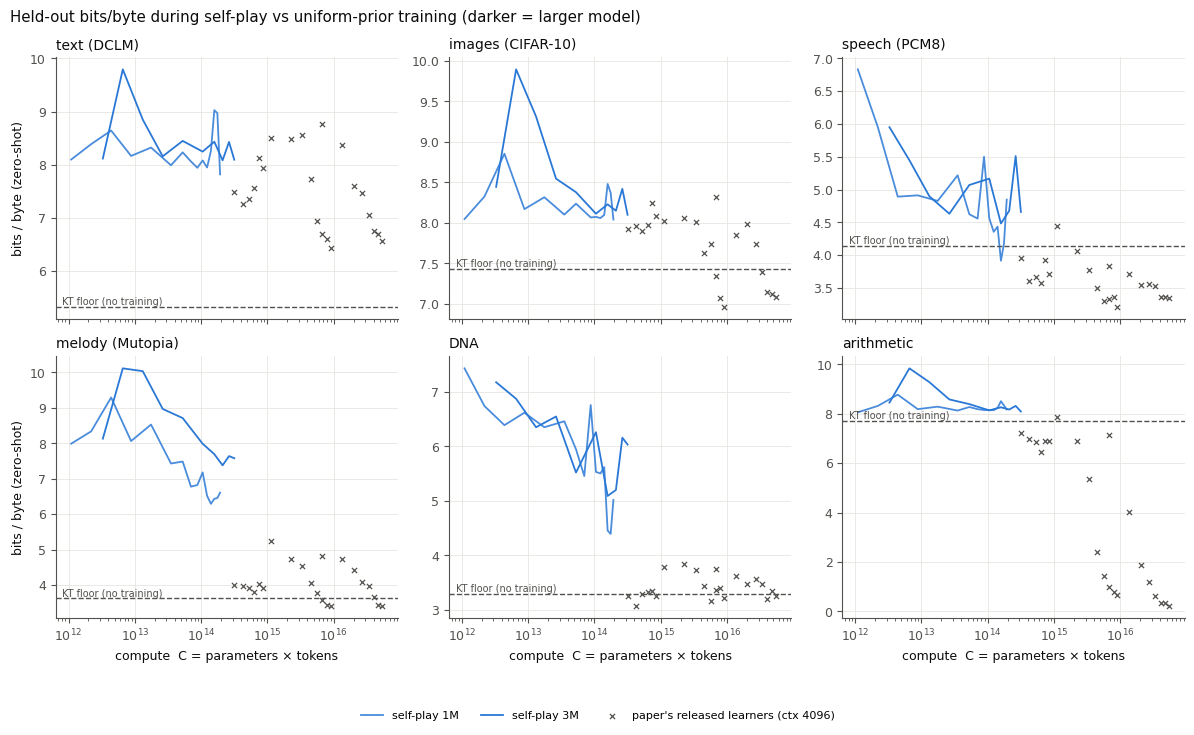

In [102]:
# 10.1  C1 + C2: zero-shot bits/byte against compute, every checkpoint of every size, both arms (seed 0).
#       Grey crosses: the AUTHORS' released self-play learners of the same sizes (their CSV, context 4096,
#       x = total params x tokens), for orientation only: a longer context makes their numbers lower.
PAPER_RUNG = {"100k": ("d64h1L1", 1024), "1M": ("d128h2L4", 1024), "3M": ("d256h4L4", 2048)}   # programs/round
from spp.model import LADDER_PARAMS
paper = list(csv.DictReader(open("ext/self_play_pretraining/figures/figure2/data/selfplay_frontier_perk.csv")))
fig, axes = plt.subplots(2, 3, figsize=(12, 6.8), sharex=True)
for ax, c in zip(axes.flat, SHOW):
    for arm in ("uniform", "selfplay"):
        for k, rung in enumerate(RUNG_ORDER):
            r = by.get((rung, arm, 0))
            if not r:
                continue
            ev = [e for e in r["evals"] if e["compute"] > 0]
            ax.plot([e["compute"] for e in ev], [e["bpb"][c] for e in ev], color=shade(ARM_COLOR[arm], k),
                    lw=1.3, label=f"{ARM_NAME[arm]} {rung}" if c == SHOW[0] else None)
    for rung, (tag, ppr) in PAPER_RUNG.items():
        pts = sorted((int(p["round"]), float(p["bpb"])) for p in paper
                     if p["rung"] == tag and p["corpus"] == c and p["K"] == "1" and 0 < int(p["round"]) <= 2048)
        ax.scatter([LADDER_PARAMS[rung] * rd * ppr * 4095 for rd, _ in pts], [b for _, b in pts], marker="x",
                   s=14, lw=0.9, color=MUTED, zorder=3, label="paper's released learners (ctx 4096)"
                   if c == SHOW[0] and rung == "100k" else None)
    ax.axhline(KT[c]["order0"], color=MUTED, ls="--", lw=1)
    ax.annotate("KT floor (no training)", (0.02, KT[c]["order0"]), xycoords=("axes fraction", "data"),
                color=MUTED, fontsize=7, va="bottom")
    ax.set_xscale("log")
    ax.set_title(LABEL[c], color=INK, fontsize=10, loc="left")
for ax in axes[1]: ax.set_xlabel("compute  C = parameters × tokens")
for ax in axes[:, 0]: ax.set_ylabel("bits / byte (zero-shot)")
fig.legend(loc="lower center", ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Held-out bits/byte during self-play vs uniform-prior training (darker = larger model)",
             x=0.01, ha="left", color=INK)
fig.tight_layout()
save(fig, "bpb_vs_compute")

In [103]:
# 10.2  C1: the compute-optimal frontier (over sizes and checkpoints, seed 0) and its power-law fit.
PAPER_ALPHA = {"dclm": 0.123, "cifar10_rgb_hwc": 0.066, "audio_8bit": 0.260, "mutopia_melody_16th": 0.249, "dna": 0.435}
print(f"{'corpus':20s} {'arm':15s} {'points':>6s} {'E':>6s} {'alpha':>7s}  {'frontier bpb: first -> last':>28s}   paper alpha")
FITS = {}
for c in SHOW:
    for arm in ("selfplay", "uniform"):
        rs = [r for (rung, a, s), r in by.items() if a == arm and s == 0]
        if not rs:
            continue
        f = frontier(points(rs, c))
        p = fit(f) if len(f) >= 4 else None
        FITS[(c, arm)] = (f, p)
        E, A, a = p if p else (np.nan,) * 3
        print(f"{LABEL[c]:20s} {ARM_NAME[arm]:15s} {len(f):6d} {E:6.2f} {a:7.3f}  {f[0, 1]:13.3f} -> {f[-1, 1]:.3f}   "
              + (f"{PAPER_ALPHA[c]:.3f}" if arm == "selfplay" and c in PAPER_ALPHA else ""))

corpus               arm             points      E   alpha   frontier bpb: first -> last   paper alpha
text (DCLM)          self-play            4   0.00   0.006          8.099 -> 7.819   0.123
images (CIFAR-10)    self-play            2    nan     nan          8.047 -> 8.041   0.066
speech (PCM8)        self-play           10   4.07   0.520          6.833 -> 3.915   0.260
melody (Mutopia)     self-play            5   0.00   0.043          7.989 -> 6.291   0.249
DNA                  self-play            9   0.00   0.085          7.429 -> 4.396   0.435
arithmetic           self-play            1    nan     nan          8.056 -> 8.056   


In [ ]:
# 10.3  C2: self-play against the uniform prior at the SAME size and token budget (final checkpoint,
#       all 256 held-out windows). At 1M both arms have two seeds, which sets the noise level.
def final_bpb(rung, arm, seed):
    e = FINAL.get((rung, arm, seed))
    return e["bpb"] if e else None
print(f"{'':20s}" + "".join(f"{rung:>22s}" for rung in RUNG_ORDER))
print(f"{'corpus':20s}" + "".join(f"{'self-play / uniform':>22s}" for _ in RUNG_ORDER))
for c in SHOW + ["random"]:
    row = f"{LABEL[c]:20s}"
    for rung in RUNG_ORDER:
        sp, un = final_bpb(rung, "selfplay", 0), final_bpb(rung, "uniform", 0)
        row += f"{sp[c]:9.3f} / {un[c]:5.3f} {'<' if sp[c] < un[c] else '>'}  " if sp and un else f"{'-':>22s}"
    print(row)
print("\nAt 1M, two seeds per arm: gap = mean(self-play) - mean(uniform); spread = largest seed-to-seed difference within an arm")
for c in SHOW:
    sp = [final_bpb("1M", "selfplay", s) for s in (0, 1)]
    un = [final_bpb("1M", "uniform", s) for s in (0, 1)]
    if None in sp + un:
        continue
    sp, un = np.array([x[c] for x in sp]), np.array([x[c] for x in un])
    gap, spread = sp.mean() - un.mean(), max(np.ptp(sp), np.ptp(un))
    verdict = "self-play better" if gap < -spread else "uniform better" if gap > spread else "within seed noise"
    print(f"  {LABEL[c]:20s} gap {gap:+.3f}   seed spread {spread:.3f}   -> {verdict}")

In [ ]:
# 10.4  C3: the reward ablation at 1M. `shuffle` keeps the generator, the pool, the reward's
#       distribution, everything, but permutes which program earned which reward every round.
arms = {"selfplay": [final_bpb("1M", "selfplay", s) for s in (0, 1)],
        "shuffle": [final_bpb("1M", "shuffle", s) for s in (0, 1)]}
print(f"{'corpus':20s} {'canonical (2 seeds)':>22s} {'shuffled (2 seeds)':>22s} {'gap':>7s} {'spread':>7s}")
for c in SHOW:
    if any(x is None for v in arms.values() for x in v):
        print("waiting for the Phase B runs"); break
    a = np.array([x[c] for x in arms["selfplay"]]); b = np.array([x[c] for x in arms["shuffle"]])
    gap, spread = b.mean() - a.mean(), max(np.ptp(a), np.ptp(b))
    print(f"{LABEL[c]:20s} {a[0]:10.3f} {a[1]:10.3f}  {b[0]:10.3f} {b[1]:10.3f}  {gap:+7.3f} {spread:7.3f}   "
          + ("canonical better" if gap > spread else "shuffled better" if gap < -spread else "within seed noise"))
print("\npaper, Table 5 (1M, 4-seed ensembles): shuffle is worse than canonical on 9 of 10 datasets, by 0.2 to 1.2 bits")

In [ ]:
%%writefile scripts/final_eval.py
"""Score every finished run's last learner on the full held-out windows and the ICL tasks.

    python scripts/final_eval.py            # writes runs/<run>/final_eval.json, data/kt_baselines.json
"""
import glob
import json
import os
import sys

import torch

sys.path.insert(0, ".")
from spp.evals import CORPORA, ICL_MS, ICL_TASKS, bpb, icl_accuracy, kt_bpb, load_corpora
from spp.model import ByteLlama

corp = load_corpora("data/c512", 256)
if not os.path.exists("data/kt_baselines.json"):
    kt = {c: {f"order{k}": kt_bpb(a, k) for k in (0, 1, 2)} for c, a in corp.items()}
    json.dump(kt, open("data/kt_baselines.json", "w"), indent=1)
    print("KT baselines:", json.dumps(kt, indent=1), flush=True)

for run in sorted(glob.glob("runs/*/final.json")):
    d = os.path.dirname(run)
    if os.path.exists(f"{d}/final_eval.json"):
        continue
    cfg = json.load(open(f"{d}/config.json"))
    ckpt = sorted(glob.glob(f"{d}/learner_*.pt"))[-1]
    m = ByteLlama.rung(cfg["rung"], cfg["T"] + 1).cuda()
    m.load_state_dict({k: v.float() for k, v in torch.load(ckpt).items()})
    m.eval()
    res = dict(ckpt=ckpt, bpb={c: bpb(m, a) for c, a in corp.items()}, icl={})
    for t in ICL_TASKS:
        res["icl"][t] = {m_: icl_accuracy(m, t, m_, trials=256, seed=7) for m_ in ICL_MS}
    json.dump(res, open(f"{d}/final_eval.json", "w"), indent=1)
    print(d, {c: round(v, 3) for c, v in res["bpb"].items()}, flush=True)

In [ ]:
# 10.5  C4: in-context learning on held-out tasks, final 1M and 3M learners. Run the final evaluation first
#       (it scores every finished run once; ~1 min per run):   !python scripts/final_eval.py
from spp.evals import ICL_TASKS, ICL_MS
fig, axes = plt.subplots(1, 6, figsize=(14, 2.9), sharey=True)
for ax, t in zip(axes, ICL_TASKS):
    for arm in ("uniform", "shuffle", "selfplay"):
        for k, rung in ((2, "1M"), (3, "3M")):
            e = FINAL.get((rung, arm, 0))
            if not e:
                continue
            ms = [m for m in ICL_MS if e["icl"][t].get(str(m)) is not None]
            ax.plot([max(m, 0.5) for m in ms], [e["icl"][t][str(m)] for m in ms], marker="o", ms=3,
                    color=shade(ARM_COLOR[arm], k), label=f"{ARM_NAME[arm]} {rung}" if t == ICL_TASKS[0] else None)
    ax.set_xscale("log"); ax.set_title(t, loc="left", color=INK)
    ax.set_xlabel("demonstrations m")
axes[0].set_ylabel("exact-match accuracy")
fig.legend(loc="lower center", ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.12))
fig.suptitle("In-context learning on tasks never seen in training (m = 0 drawn at 0.5)", x=0.01, ha="left", color=INK)
fig.tight_layout()
save(fig, "icl")

In [ ]:
%%writefile scripts/prior_discovery.py
"""How often does the fixed prior g0 produce each mathematical family by chance? (Table 1, last column)

    "we sample programs by uniformly sampling the primitive augmented alphabet until an "F"
     symbol is drawn. We draw 1.64 x 10^8 programs in total. [...] The arithmetic family occurs
     1,526 times in the uniform baseline, giving an estimated probability of 9.3 x 10^-6"  (App. C)

Same procedure at this reproduction's tape length (T = 511) and length cap (128). Writes
results/prior_discovery.json with per-family hit counts; the expected first-discovery round at
R programs per round is 1 / (R p), with the rule of three (p <= 3/N) when a family never appears.

    python scripts/prior_discovery.py --n 20000000
"""
import argparse
import json
import sys
import time

import numpy as np

sys.path.insert(0, ".")
from spp.machine import execute, sample_uniform_prior
from spp.structure import FAMILIES, scan

ap = argparse.ArgumentParser()
ap.add_argument("--n", type=int, default=20_000_000)
ap.add_argument("--chunk", type=int, default=65_536)
ap.add_argument("--T", type=int, default=511)
ap.add_argument("--out", default="results/prior_discovery.json")
args = ap.parse_args()

rng = np.random.default_rng(2026)
counts, examples, done, t0 = {f: 0 for f in FAMILIES}, {}, 0, time.time()
while done < args.n:
    bodies, _ = sample_uniform_prior(args.chunk, 128, rng)
    for i, h in scan(execute(bodies, args.T, seed=done)["out"]):
        counts[h["family"]] += 1
        examples.setdefault(h["family"], dict(program=bodies[i].decode(), terms=h["first_terms"]))
    done += args.chunk
    if done % (args.chunk * 32) == 0:
        print(f"{done:,} programs  {time.time() - t0:.0f}s  {counts}", flush=True)
        json.dump(dict(samples=done, T=args.T, hit_counts=counts, examples=examples), open(args.out, "w"), indent=1)
json.dump(dict(samples=done, T=args.T, hit_counts=counts, examples=examples), open(args.out, "w"), indent=1)
print("final", done, counts)

In [ ]:
# The chance baseline for C5: 10M programs from g0, executed and scanned (~5 min on 16 CPU cores, ~20 on 4).
if not os.path.exists("results/prior_discovery.json"):
    subprocess.run("python -u scripts/prior_discovery.py --n 10000000", shell=True, check=True)
print(json.load(open("results/prior_discovery.json"))["hit_counts"])

In [ ]:
# 10.6  C5: how often each run's pools contained each mathematical family, against the rate at which
#       the fixed prior g0 produces it BY CHANCE at the same tape length (10M programs, scripts/prior_discovery.py).
#       At 511-byte tapes every family occurs by chance, so the test is a RATE (enrichment), not a first sighting.
from scipy.stats import chi2
from spp.structure import FAMILIES
prior = json.load(open("results/prior_discovery.json"))
N = prior["samples"]
p0 = {f: prior["hit_counts"][f] / N for f in FAMILIES}
def poisson_ci(k, n):
    lo = chi2.ppf(0.025, 2 * k) / 2 / n if k else 0.0
    return lo, chi2.ppf(0.975, 2 * k + 2) / 2 / n
print(f"chance rate under g0 at T = 511 ({N:,} programs):  " + "  ".join(f"{f} {p0[f]:.1e}" for f in FAMILIES))
print(f"\n{'run':24s} {'programs':>9s}  " + "".join(f"{f:>20s}" for f in FAMILIES))
print(f"{'':24s} {'scanned':>9s}  " + "".join(f"{'hits  (x chance)':>20s}" for f in FAMILIES))
ENRICH = {}
for (rung, arm, seed), r in sorted(by.items(), key=lambda kv: (kv[0][1], RUNG_ORDER.index(kv[0][0]), kv[0][2])):
    fin = r["final"]
    if not fin:
        continue
    n = fin["config"]["rounds"] * (256 if arm == "uniform" else 224)   # non-replay programs scanned
    cells = []
    for f in FAMILIES:
        k = fin["hit_counts"][f]
        lo, hi = poisson_ci(k, n)
        ENRICH[(rung, arm, seed, f)] = (k, k / n / p0[f], lo / p0[f], hi / p0[f])
        cells.append(f"{k:5d} ({k / n / p0[f]:5.1f}x)")
    print(f"{rung + ' ' + ARM_NAME[arm] + ' s' + str(seed):24s} {n:9,d}  " + "".join(f"{c:>20s}" for c in cells))
print("\n(x chance) = observed rate / g0 rate; 95% Poisson intervals are in ENRICH. The uniform arm should sit near 1x.")
print("\nFirst program of each non-arithmetic family written by a self-play generator:")
shown = set()
for (rung, arm, seed), r in sorted(by.items()):
    for f, fs in (r["final"] or {}).get("first_seen", {}).items():
        if f != "arithmetic" and f not in shown and arm != "uniform":
            shown.add(f)
            print(f"  {f:10s} {rung} {ARM_NAME[arm]} round {fs['round']}: S{fs['program']}F  ->  {fs['terms']}")

In [ ]:
# 10.7  Inside the loop: how the generator moves away from g0, and what it writes.
panels = [("kl", "KL(g_phi || g0)  [nats]"), ("body_len", "mean program length"),
          ("full_frac", "fraction of full 511-byte tapes"), ("r_mean", "mean reward |r|")]
fig, axes = plt.subplots(1, 4, figsize=(14, 2.9))
for ax, (key, title) in zip(axes, panels):
    for (rung, arm, seed), r in sorted(by.items()):
        if arm == "uniform" or rung != "1M" and not (rung == "3M" and seed == 0):
            continue
        tr = r["train"]
        ax.plot([t["round"] for t in tr], [t[key] for t in tr], lw=1.1,
                color=shade(ARM_COLOR[arm], 3 if rung == "3M" else 2 - seed),
                label=f"{ARM_NAME[arm]} {rung} s{seed}" if key == "kl" else None)
    ax.set_title(title, loc="left", color=INK); ax.set_xlabel("round")
fig.legend(loc="lower center", ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
save(fig, "generator_dynamics")
r = by.get(("1M", "selfplay", 0))
if r:
    for e in r["evals"]:
        if e["round"] in (0, 256, 1024, 2048):
            print(f"round {e['round']:4d}:", "  ".join(p for p in e["programs"][:6]))

In [3]:
import subprocess, datetime
print(datetime.datetime.now())
print(subprocess.run("uptime; ls /kaggle/working; ls /kaggle/working/self-play-pretraining-zero-data/runs 2>&1 | head; ls /kaggle/working/self-play-pretraining-zero-data/results 2>&1; ps -eo pid,etime,args | grep -E 'spp[.]selfplay|queue[.]py|calibration' | cut -c1-110; nvidia-smi --query-gpu=index,utilization.gpu,memory.used --format=csv,noheader", shell=True, capture_output=True, text=True).stdout)

2026-09-26 08:26:46.839963
 08:26:46 up 44 min,  0 user,  load average: 0.39, 0.27, 0.24
ls: cannot access '/kaggle/working/self-play-pretraining-zero-data/runs': No such file or directory
ls: cannot access '/kaggle/working/self-play-pretraining-zero-data/results': No such file or directory
  10664       00:00 /bin/sh -c uptime; ls /kaggle/working; ls /kaggle/working/self-play-pretraining-zero-data/
  10671       00:00 grep -E spp[.]selfplay|queue[.]py|calibration

